## Colab setup (don't if local)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import os
import sys
ROOT_PATH = "/content/drive/MyDrive/chiliSummerProject/src"
print(os.listdir(ROOT_PATH))
sys.path.append(ROOT_PATH)

## Setup always

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import pprint as p
from define_model import *
from helpers.data_helpers import *
from helpers.metrics_helpers import *
from helpers.plot_helpers import *
from scipy import stats

In [ ]:
#set random seeds
seed = 0
random.seed(seed)
np.random.seed(seed)
#data paths
drive = 1 # 1 if on google drive, 0 if not
data_dir = "/content/drive/MyDrive/chiliSummerProject/data/" if drive else "../data/"
model_path = "/content/drive/MyDrive/chiliSummerProject/models/" if drive else "../models/"
chili_models = model_path + "chili_models/"
identifier_eth = "TouchPose_crossGestures"
data_path_eth = data_dir + "eth_data/"
data_path_chili= data_dir + "processed/native_mapped/map_7ms/"

## Read data

**Read touchpose data**

In [ ]:
files = glob.glob(data_path_eth+'*.pkl')
df_eth = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
#all negative values to 0
df_eth['cap_img']= df_eth['cap_img'].apply(lambda x : np.where(x>0, x, 0))
print(len(df_eth))
df_eth.head()

65374


,cap_img,data_id,depth_img,filename,gesture_id,session_id,subject_id,touch_id
0,"[[0, 0, 0, 5, 4, 0, 2, 0, 1, 0, 0, 0, 2, 1, 0,...",635.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 3_00000635.npz,66.0,right_hand_1,P10,3.0
1,"[[0, 0, 7, 0, 2, 4, 0, 0, 2, 2, 1, 0, 0, 3, 4,...",636.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 3_00000636.npz,66.0,right_hand_1,P10,3.0
2,"[[0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 3,...",637.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 3_00000637.npz,66.0,right_hand_1,P10,3.0
3,"[[0, 0, 1, 3, 3, 0, 2, 1, 2, 0, 0, 4, 0, 5, 3,...",638.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 3_00000638.npz,66.0,right_hand_1,P10,3.0
4,"[[0, 0, 1, 9, 0, 0, 3, 0, 0, 1, 0, 2, 4, 0, 2,...",639.0,"[[255.0, 255.0, 255.0, 255.0, 255.0, 255.0, 25...",data_g_66_ 3_00000639.npz,66.0,right_hand_1,P10,3.0


**Read chili data, choose which filtering to apply on cap_img**

In [ ]:
#chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='all', filter_cap_img = lambda x : filter_std(x,m=2))
#no filtering and no normalization applied
chili_data, skeleton_cols = read_data(keep_wrist=True, data_path=data_path_chili, norm_cap_img=False)
chili_data

before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-236.37884521484372, 307.09149169921875, 164...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DQ,1,2803
1,1.679995e+12,"[[-236.16571044921875, 307.2611694335937, 163....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DQ,1,2803
2,1.679995e+12,"[[-235.99673461914065, 307.3296203613281, 163....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DQ,1,2803
3,1.679995e+12,"[[-235.7374725341797, 307.2218322753906, 163.1...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DQ,1,2803
4,1.679995e+12,"[[-235.8541717529297, 306.91522216796875, 162....","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-288.7589416503906, 286.1890563964844, 171.7...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304
80956,1.680527e+12,"[[-289.0491943359375, 286.4190979003906, 171.4...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304
80957,1.680527e+12,"[[-288.4601745605469, 285.4347839355469, 171.5...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304
80958,1.680527e+12,"[[-289.1985168457031, 285.461181640625, 184.38...","[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",3,LT,35,0304


# TimeStamps

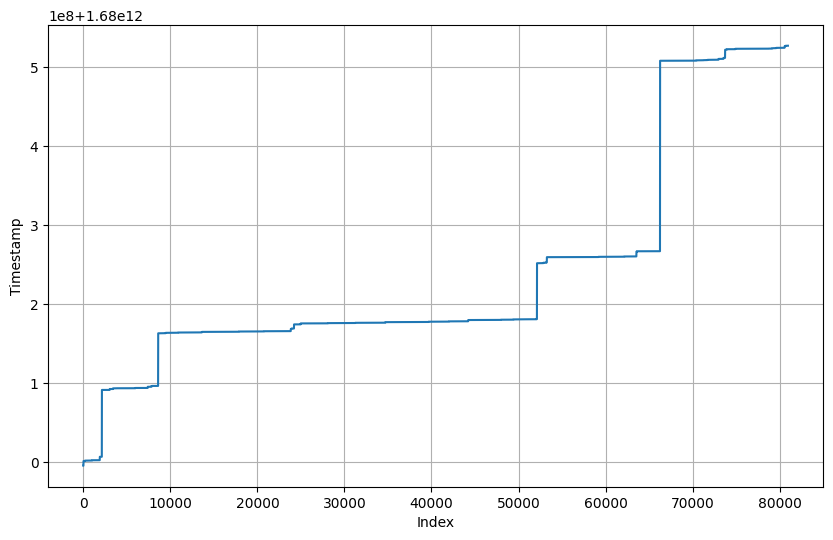

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(chili_data['Timestamp'])
plt.xlabel('Index')
plt.ylabel('Timestamp')
plt.grid(True)
plt.show()

# Categorical features

DT    26350
DQ    22377
LT    19276
LQ    12957
Name: gesture, dtype: int64

count     80960
unique        4
top          DT
freq      26350
Name: gesture, dtype: object

<Axes: >

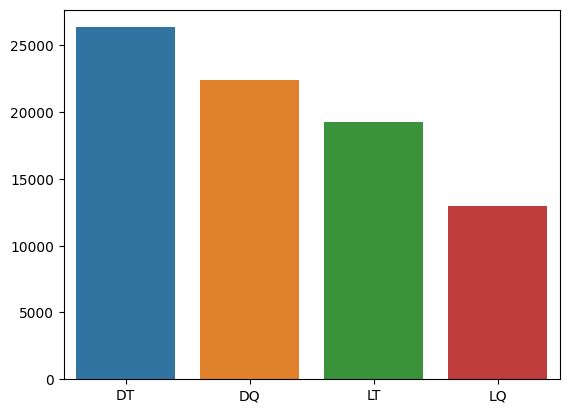

In [ ]:
display(chili_data.gesture.value_counts())
display(chili_data.gesture.describe())
sns.barplot(x=chili_data.gesture.value_counts().index, y=chili_data.gesture.value_counts().values)

<Axes: >

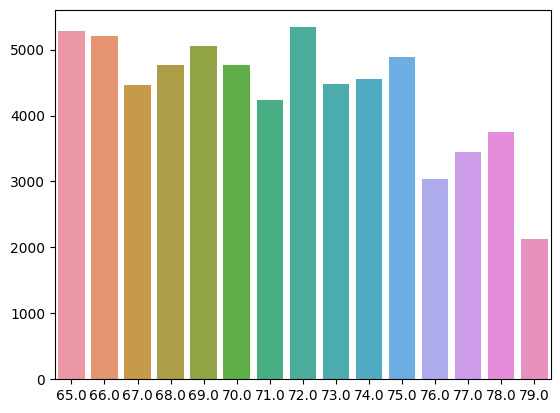

In [ ]:
sns.barplot(x=df_eth.gesture_id.value_counts().index, y=df_eth.gesture_id.value_counts().values)

2    19747
1    17952
5    12129
6    11891
4    10229
3     9012
Name: trial, dtype: int64

count     80960
unique        6
top           2
freq      19747
Name: trial, dtype: object

<Axes: >

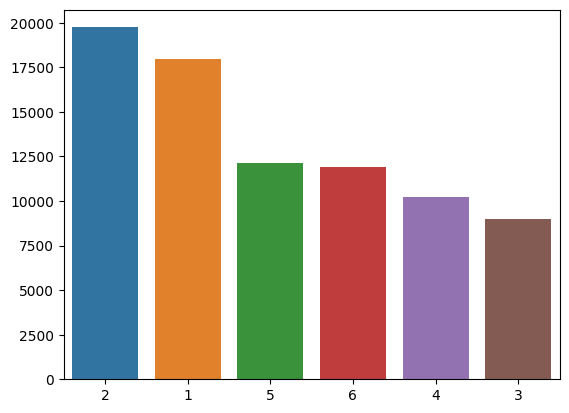

In [ ]:
display(chili_data.trial.value_counts())
display(chili_data.trial.describe())
sns.barplot(x=chili_data.trial.value_counts().index, y=chili_data.trial.value_counts().values)

<Axes: >

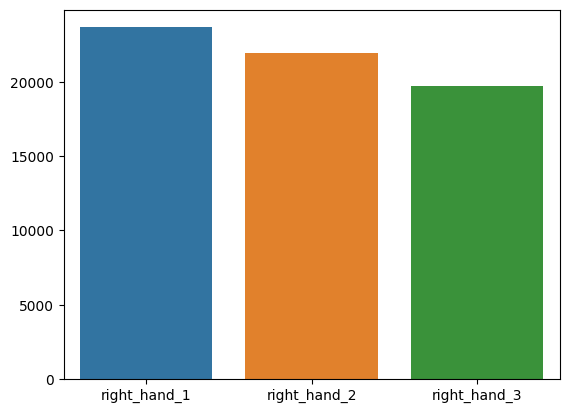

In [ ]:
sns.barplot(x=df_eth.session_id.value_counts().index, y=df_eth.session_id.value_counts().values)

24    10292
14    10216
18     9735
19     9514
20     7869
27     6722
33     5659
13     5024
11     3994
25     2716
2      1873
10     1275
12     1198
32     1176
22     1134
17      767
28      567
35      383
16      371
5       241
29      185
21       35
34        9
1         5
Name: subject, dtype: int64

<Axes: >

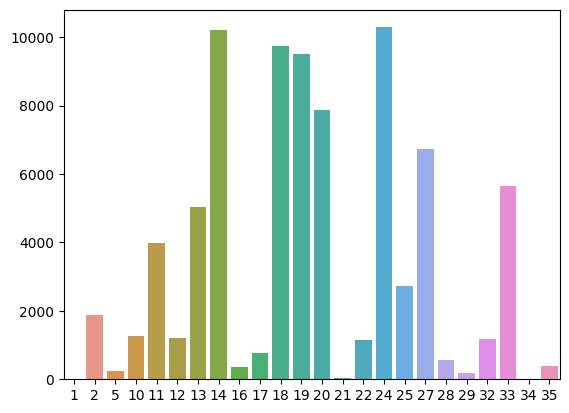

In [ ]:
display(chili_data.subject.value_counts())
chili_data.subject.describe()
sns.barplot(x=chili_data.subject.value_counts().index, y=chili_data.subject.value_counts().values)

<Axes: >

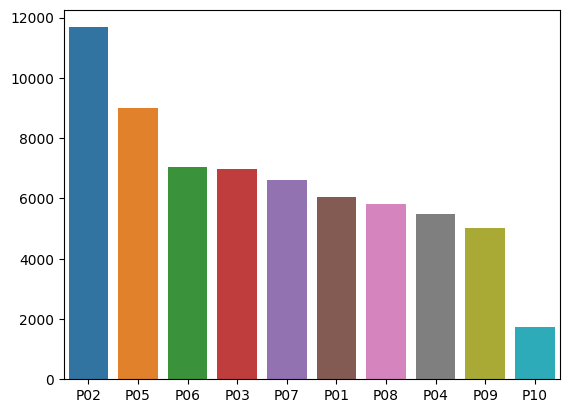

In [ ]:
sns.barplot(x=df_eth.subject_id.value_counts().index, y=df_eth.subject_id.value_counts().values)

3003    43531
0304    14701
3103    14142
2903     6467
2803     2119
Name: day, dtype: int64

<Axes: >

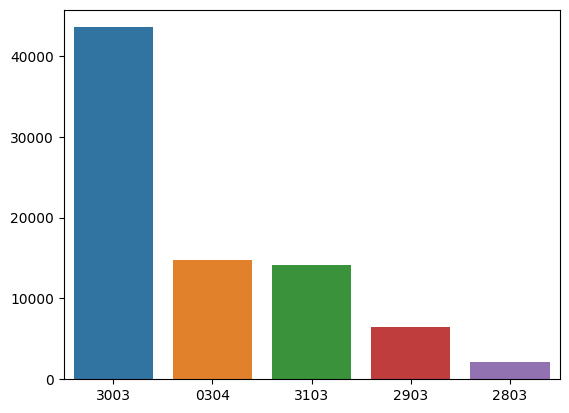

In [ ]:
display(chili_data.day.value_counts())
chili_data.day.describe()
sns.barplot(x=chili_data.day.value_counts().index, y=chili_data.day.value_counts().values)

# Capactive images comparison between chili and touchpose

### Capactive images

In [ ]:
#number of coordinates in each dataset
print(len(np.concatenate(df_eth.cap_img).ravel()))
len(np.concatenate(chili_data.cap_img).ravel())

192984048


238993920

In [ ]:
cap_data = np.concatenate(chili_data.cap_img).ravel()
cap_eth = np.concatenate(df_eth.cap_img).ravel()
cap_eth = np.where(cap_eth>0,cap_eth,0)

In [ ]:
kernel= stats.gaussian_kde(cap_data)
x=np.linspace(cap_data.min(),cap_data.max(),100)
y = kernel(x)
kernel_eth= stats.gaussian_kde(cap_eth)
x_eth=np.linspace(cap_eth.min(),cap_eth.max(),100)
y_eth = kernel_eth(x_eth)

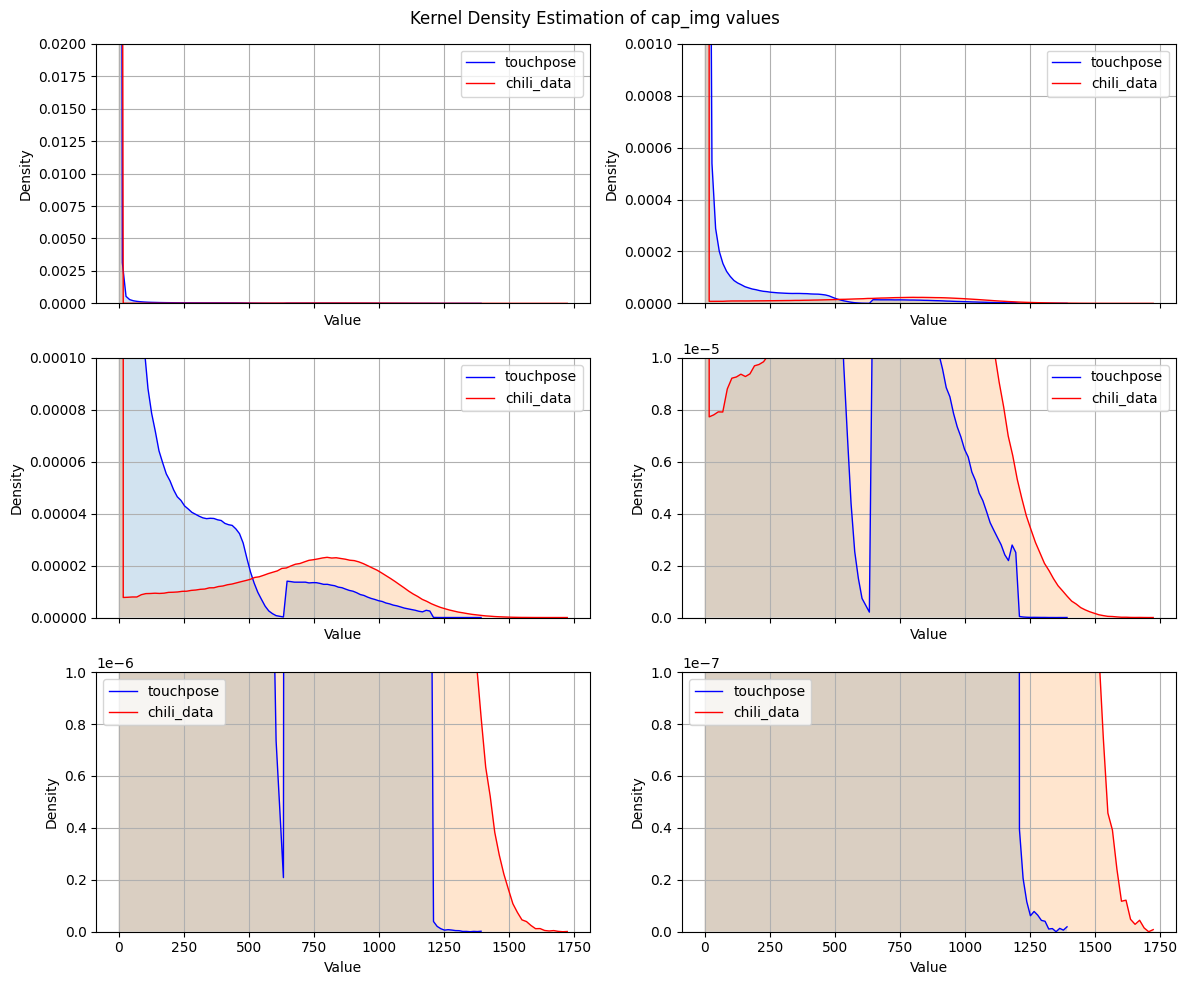

In [ ]:
def create_subplot(ax, x, y, label, color, alpha, ylim):
    ax.plot(x, y, label=label, linewidth=1, color=color)
    ax.fill_between(x, 0, y, alpha=alpha)
    ax.set_ylim(0, ylim)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.grid(True)

fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=True)

y_lim_values = [0.02, 0.001, 0.0001, 0.00001, 0.000001, 0.0000001]
labels = ['touchpose', 'chili_data']
colors = ['b', 'r']

for i, ax in enumerate(axes.ravel()):
    create_subplot(ax, x_eth, y_eth, labels[0], colors[0], 0.2, y_lim_values[i])
    create_subplot(ax, x, y, labels[1], colors[1], 0.2, y_lim_values[i])
    ax.legend()

fig.suptitle('Kernel Density Estimation of cap_img values')
plt.tight_layout()
plt.show()

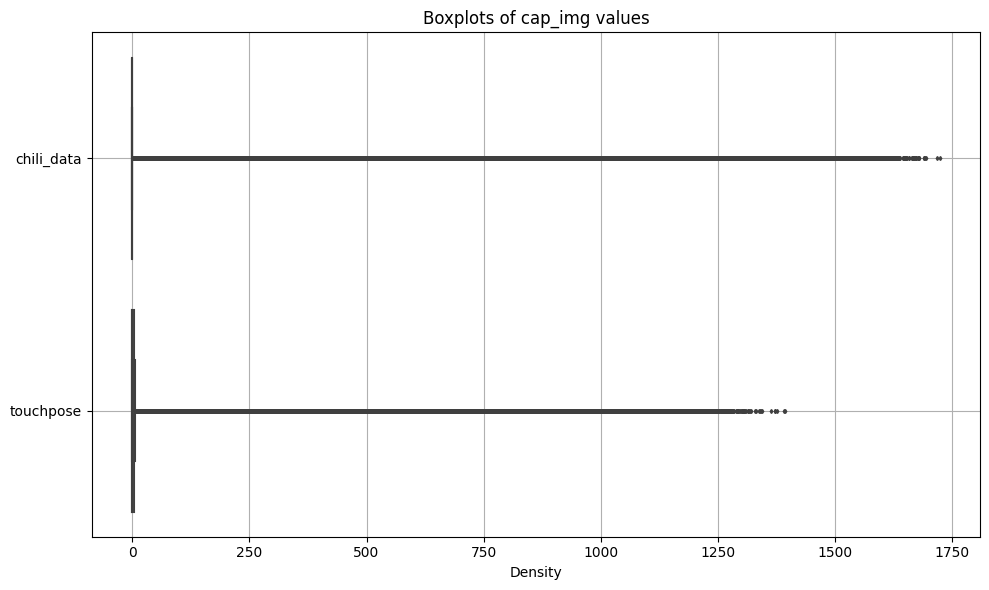

In [ ]:
boxplot_data = [cap_data, cap_eth]  # Add your actual data here
boxplot_labels = ['chili_data', 'touchpose']

# Create a boxplot using Seaborn
plt.figure(figsize=(10, 6))
sns.boxplot(data=boxplot_data, orient='h', fliersize=2)
plt.yticks([0, 1], boxplot_labels)  # Label the y-axis with the dataset names
plt.xlabel('Density')
plt.title('Boxplots of cap_img values')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

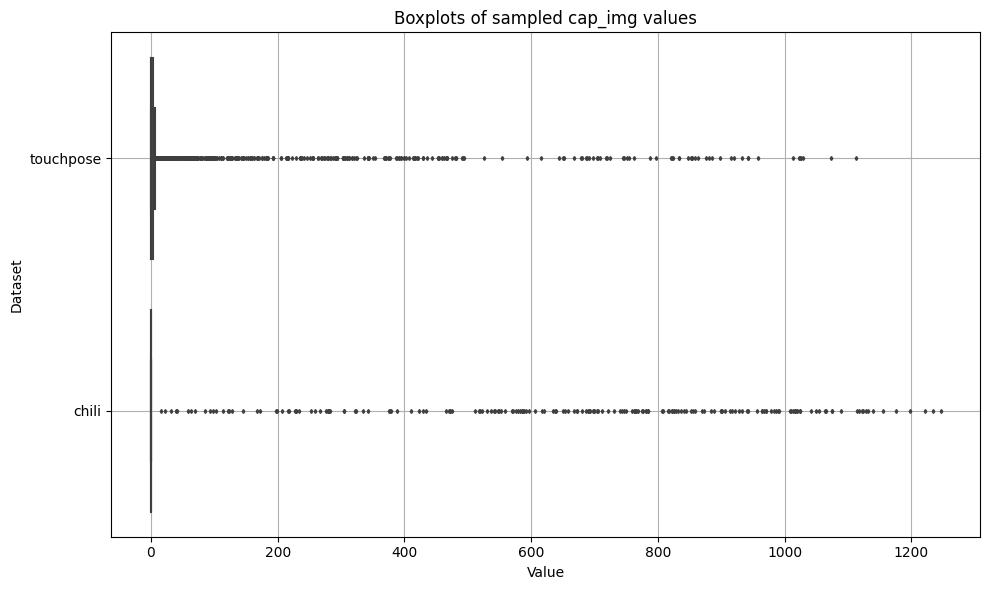

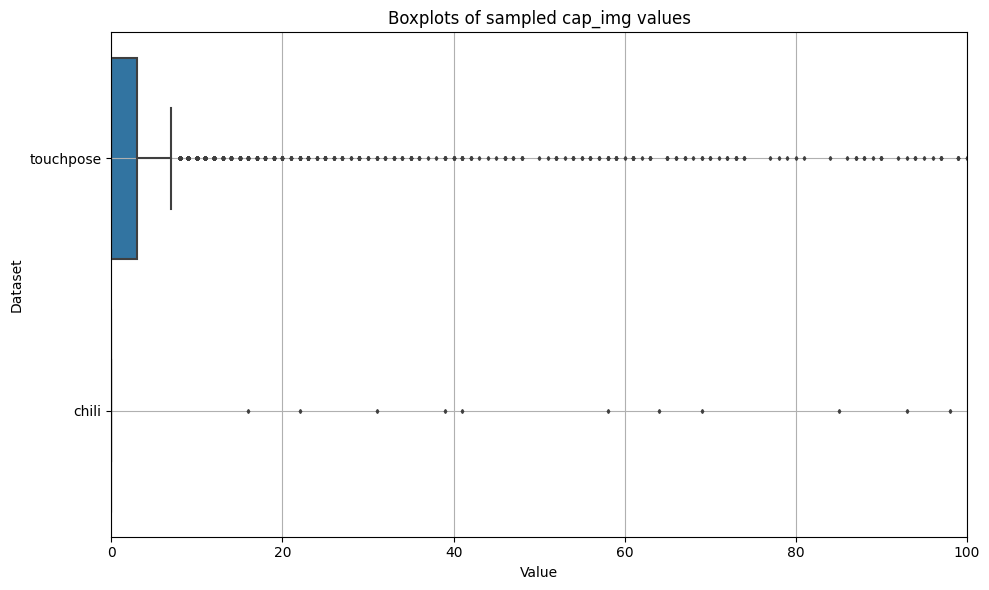

In [ ]:
sample_size = 10000
sample_cap_eth = np.random.choice(cap_eth, size=sample_size, replace=False)
sample_cap_data = np.random.choice(cap_data, size=sample_size, replace=False)

combined_data = [sample_cap_eth, sample_cap_data]

boxplot_labels = ['touchpose','chili']

plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_data, orient='h',fliersize=2)

plt.yticks([0, 1], boxplot_labels)

plt.ylabel('Dataset')
plt.xlabel('Value')
plt.title('Boxplots of sampled cap_img values')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_data, orient='h',fliersize=2)
plt.xlim(0,100)
plt.yticks([0, 1], boxplot_labels)

plt.ylabel('Dataset')
plt.xlabel('Value')
plt.title('Boxplots of sampled cap_img values')

# Show the plot
plt.grid(True)
plt.tight_layout()
plt.show()

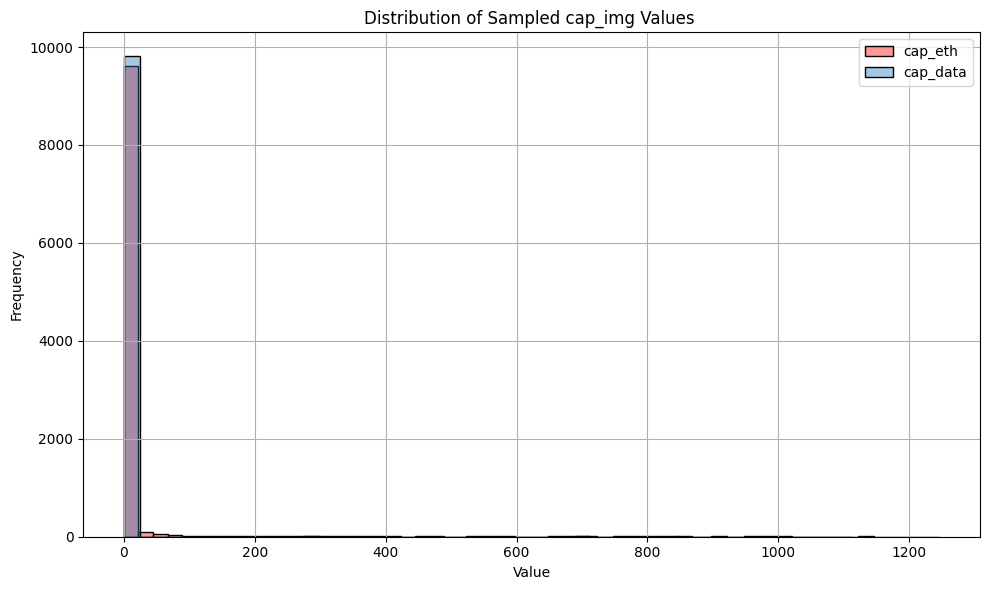

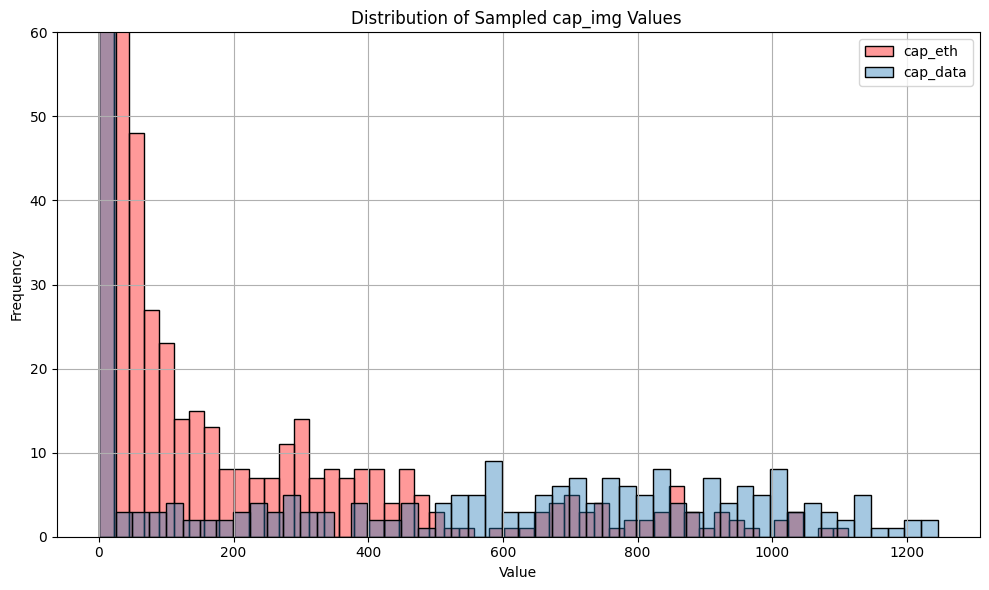

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=sample_cap_eth, bins=50, common_norm=False, edgecolor='k', alpha=0.4,label = 'cap_eth',color = 'red')
sns.histplot(data=sample_cap_data, bins=50, common_norm=False,edgecolor='k', alpha=0.4, label = 'cap_data')

plt.title('Distribution of Sampled cap_img Values ')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(data=sample_cap_eth, bins=50, common_norm=False, edgecolor='k', alpha=0.4,label = 'cap_eth',color = 'red')
sns.histplot(data=sample_cap_data, bins=50, common_norm=False,edgecolor='k', alpha=0.4, label = 'cap_data')

plt.ylim(0, 60)
plt.title('Distribution of Sampled cap_img Values ')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

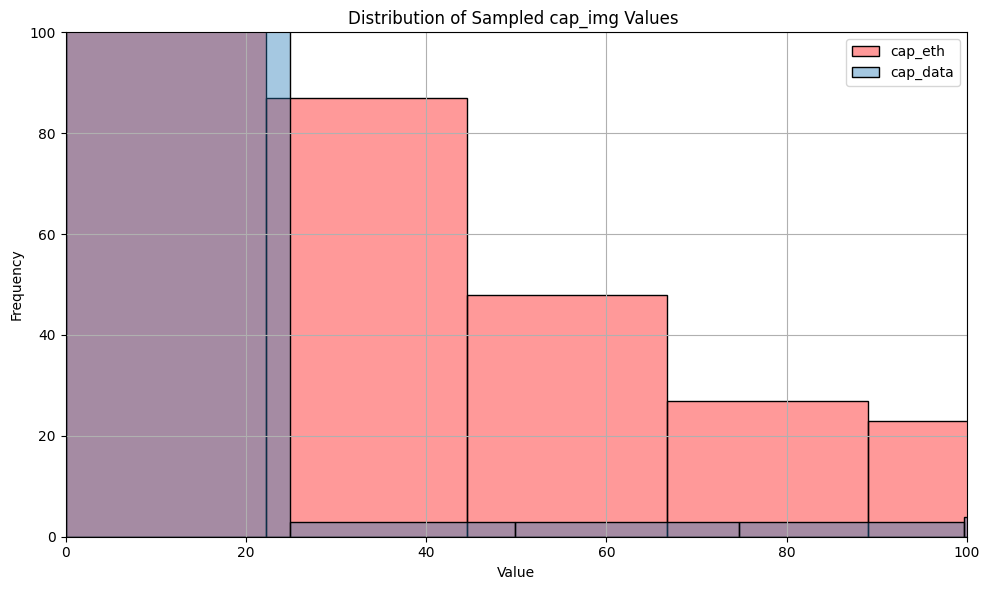

In [ ]:

plt.figure(figsize=(10, 6))
sns.histplot(data=sample_cap_eth, bins=50, common_norm=False, edgecolor='k', alpha=0.4,label = 'cap_eth',color = 'red')
sns.histplot(data=sample_cap_data, bins=50, common_norm=False,edgecolor='k', alpha=0.4, label = 'cap_data')

plt.ylim(0, 100)
plt.xlim(0,100)
plt.title('Distribution of Sampled cap_img Values ')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.legend()

plt.grid(True)
plt.tight_layout()
plt.show()

Verify samples distributions with respect to data

In [ ]:
for name,cap,sample_cap in [('chili',cap_data,sample_cap_data), ('touchpose',cap_eth,sample_cap_eth)] :
  mean_data = np.mean(cap)
  std_data = np.std(cap)
  median_data = np.median(cap)
  quantiles_data = np.percentile(cap, [25, 50, 75])

  mean_sample_data = np.mean(sample_cap)
  std_sample_data = np.std(sample_cap)
  median_sample_data = np.median(sample_cap)
  quantiles_sample_data = np.percentile(sample_cap, [25, 50, 75])

  print(f"\nOriginal Data {name}:")
  print(f"Mean: {mean_data}")
  print(f"Standard Deviation: {std_data}")
  print(f"Median: {median_data}")
  print(f"Quantiles (25th, 50th, 75th): {quantiles_data}")

  print(f"\nSampled Data {name}:")
  print(f"Mean: {mean_sample_data}")
  print(f"Standard Deviation: {std_sample_data}")
  print(f"Median: {median_sample_data}")
  print(f"Quantiles (25th, 50th, 75th): {quantiles_sample_data}")



Original Data chili:
Mean: 12.266781489671368
Standard Deviation: 99.72965806691737
Median: 0.0
Quantiles (25th, 50th, 75th): [0. 0. 0.]

Sampled Data chili:
Mean: 12.6681
Standard Deviation: 100.71234056653634
Median: 0.0
Quantiles (25th, 50th, 75th): [0. 0. 0.]

Original Data touchpose:
Mean: 12.199399289209644
Standard Deviation: 72.68230709897306
Median: 0.0
Quantiles (25th, 50th, 75th): [0. 0. 3.]

Sampled Data touchpose:
Mean: 11.5998
Standard Deviation: 70.88575202366128
Median: 0.0
Quantiles (25th, 50th, 75th): [0. 0. 3.]


some stats about each cap images data

In [ ]:
index_ch = np.argwhere(cap_data==0)
chili_zeroes= (len(index_ch)/len(cap_data))*100
index_th = np.argwhere(cap_eth==0)
touch_zeroes= (len(index_th)/len(cap_eth))*100
print(f'Percentage of zeroes , chili: {chili_zeroes}, touchpose : {touch_zeroes}')

Percentage of zeroes , chili: 98.18792754225714, touchpose : 53.8208805735073


In [ ]:
index_ch = np.argwhere(cap_data<5)
f_cap_data = np.delete(cap_data,index_ch)
np.mean(f_cap_data)

678.102170728108

In [ ]:
index_th = np.argwhere(cap_eth<5)
f_touch_data = np.delete(cap_eth,index_th)
np.mean(cap_eth)

12.199399289209644

In [ ]:
np.std(f_cap_data),np.std(f_touch_data)

(313.5439000742158, 155.71205114863906)

stats of non empty cap images

In [ ]:
chili_data.cap_img.apply(lambda x : len(x[x!=0])).describe()

count    80960.000000
mean        53.492379
std         35.268191
min          1.000000
25%         27.000000
50%         49.000000
75%         76.000000
max        321.000000
Name: cap_img, dtype: float64

In [ ]:
df_eth.cap_img.apply(lambda x : len(x[x!=0])).describe()

count    65374.000000
mean      1363.207605
std         68.934521
min       1150.000000
25%       1316.000000
50%       1357.000000
75%       1401.000000
max       1711.000000
Name: cap_img, dtype: float64

In [ ]:
ranking=chili_data.cap_img.apply(lambda x : len(x[x!=0])).sort_values()
ranking

80959      1
63427      1
63428      1
63543      1
63551      1
        ... 
53163    318
53140    319
53159    320
53130    320
53153    321
Name: cap_img, Length: 80960, dtype: int64

we can plot capactive images and skeleton coordinates of the less and most dense samples

In [ ]:
ranking.value_counts()

28     1129
30     1116
27     1102
24     1100
26     1082
       ... 
261       1
265       1
272       1
281       1
321       1
Name: cap_img, Length: 259, dtype: int64

In [ ]:
#less dense samples
ranking[:5].index

Int64Index([80959, 63427, 63428, 63543, 63551], dtype='int64')

In [ ]:
#most dense samples
ranking[-5:].index

Int64Index([53163, 53140, 53159, 53130, 53153], dtype='int64')

In [ ]:
y_less, y_most = np.stack(chili_data.loc[ranking[:5].index].skeleton.values), np.stack(chili_data.loc[ranking[-5:].index].skeleton.values)
x_less, x_most = np.stack(chili_data.loc[ranking[:5].index].cap_img.values), np.stack(chili_data.loc[ranking[-5:].index].cap_img.values)

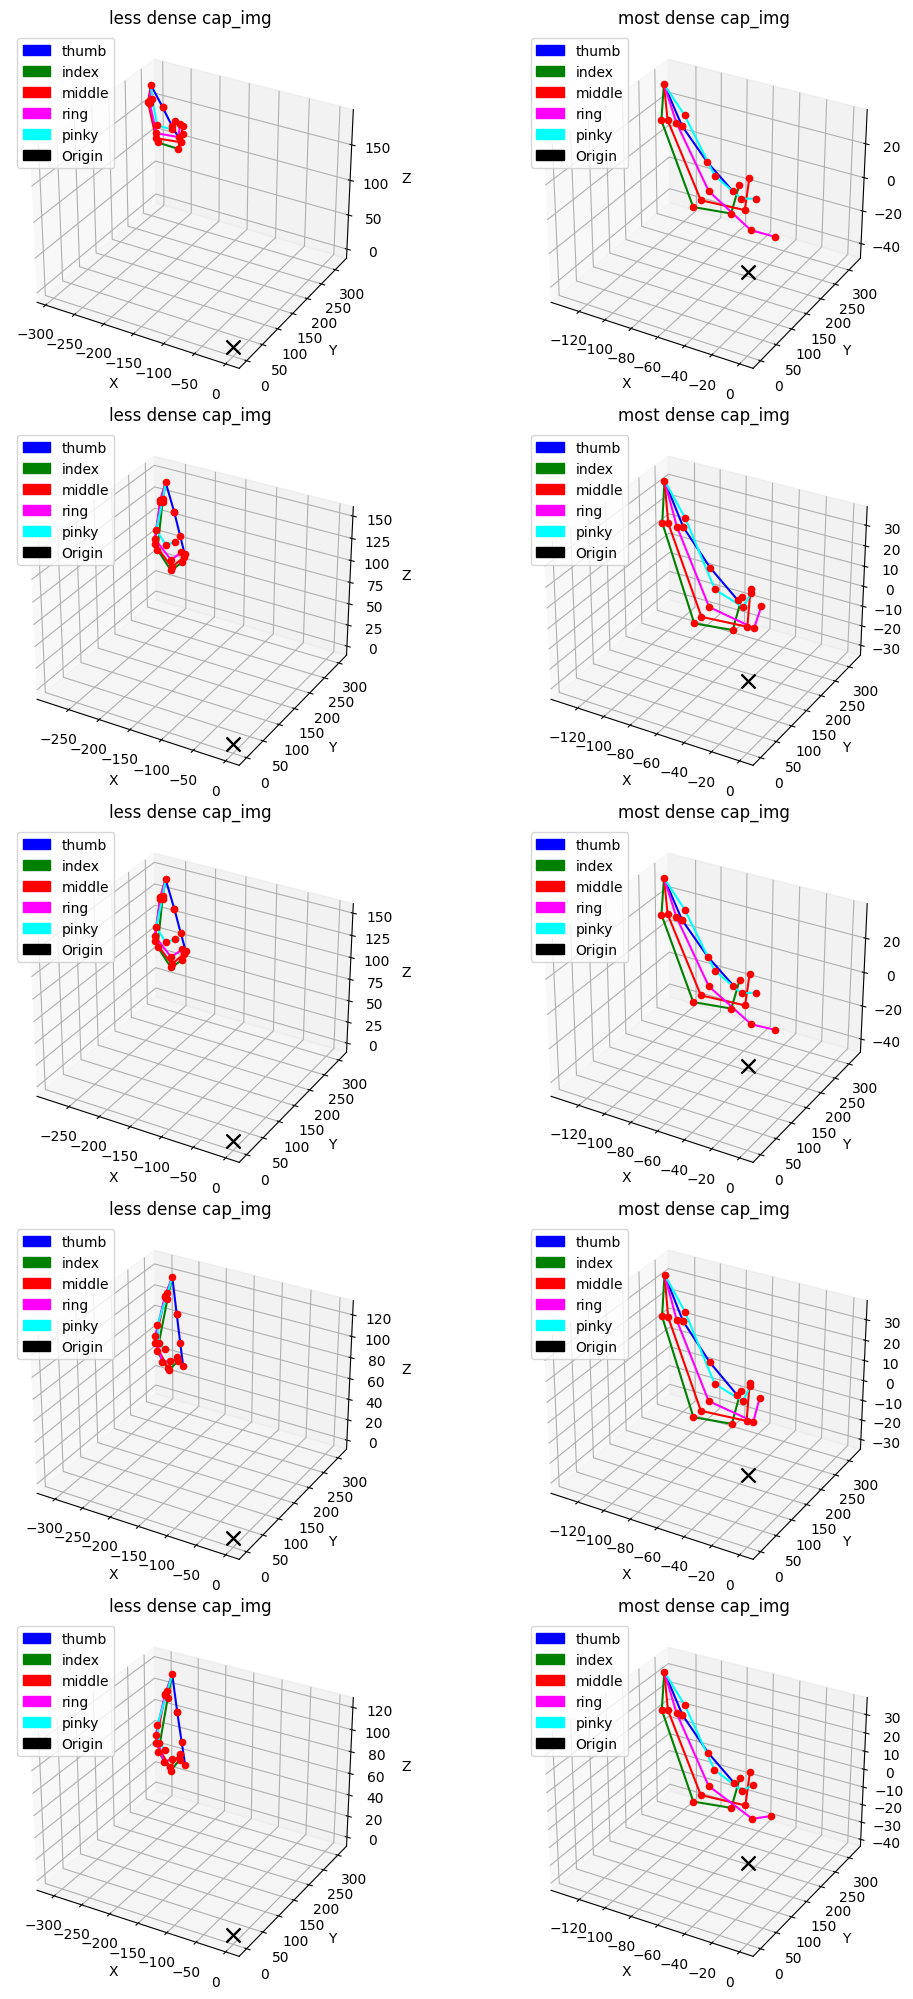

In [ ]:
plot_hand_compare(y_less, y_most, title1 = 'less dense cap_img', title2 = 'most dense cap_img' )

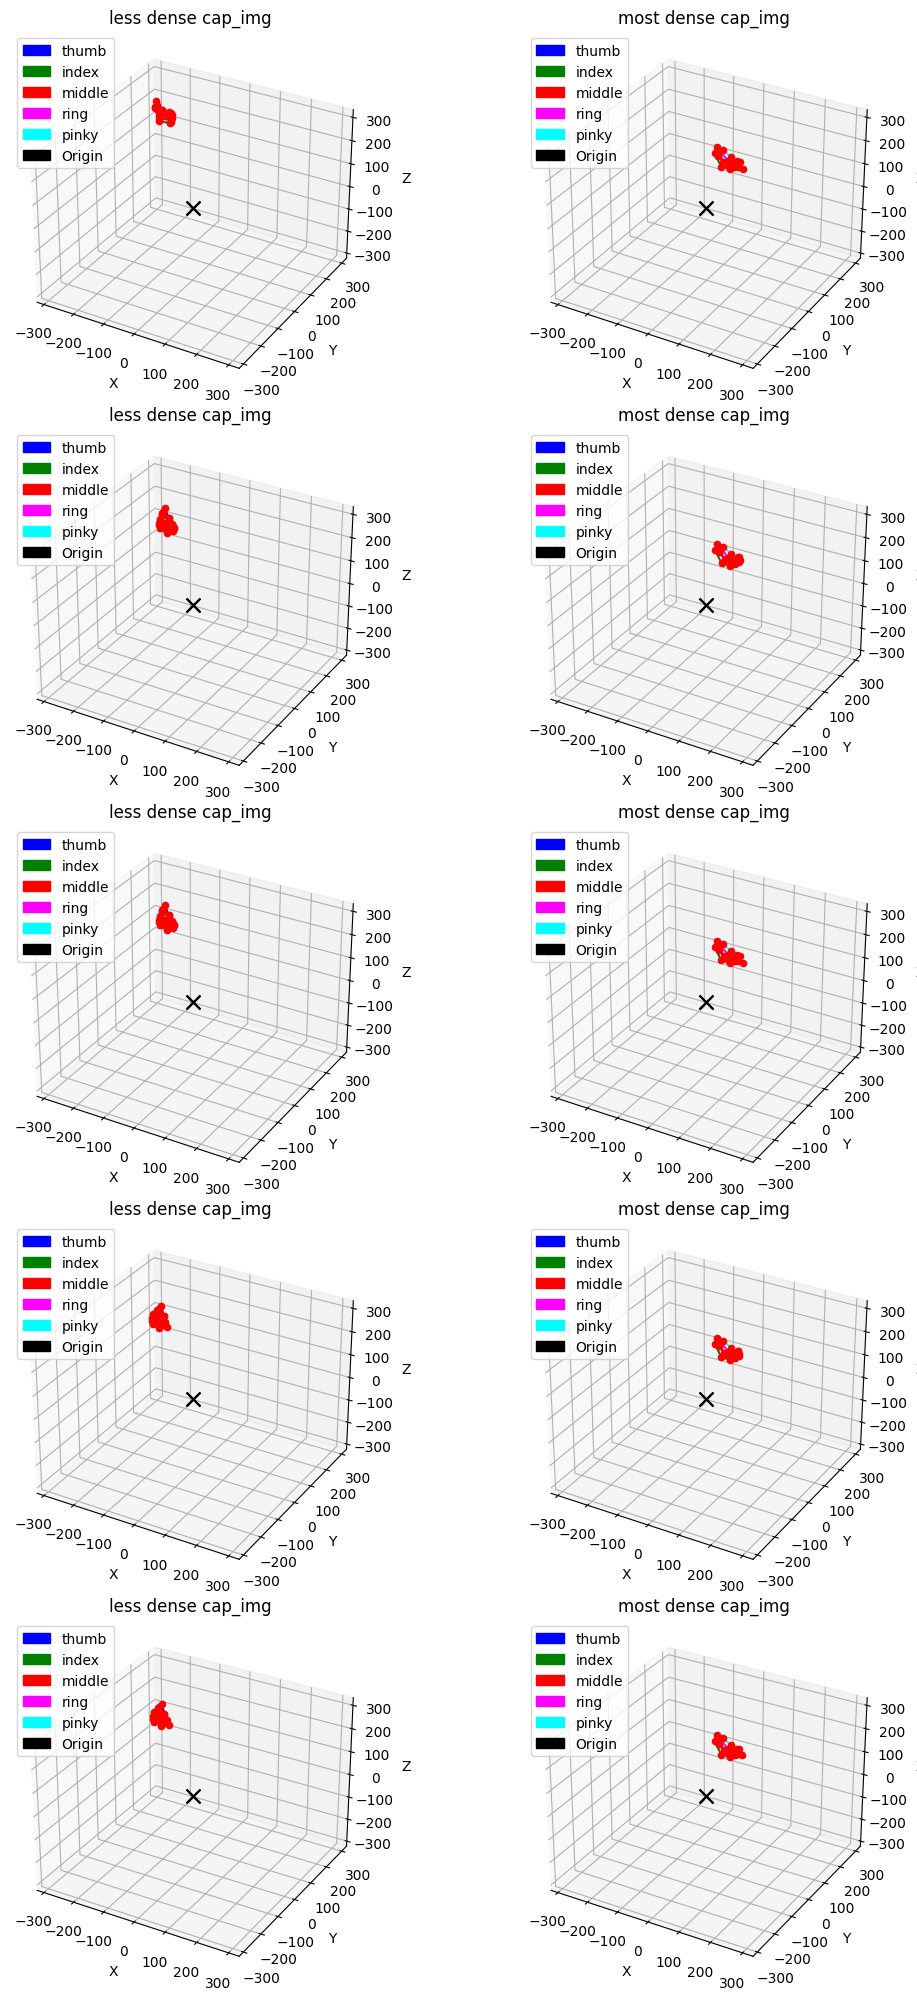

In [ ]:
plot_hand_compare(y_less, y_most, title1 = 'less dense cap_img', title2 = 'most dense cap_img', same_axis = True)

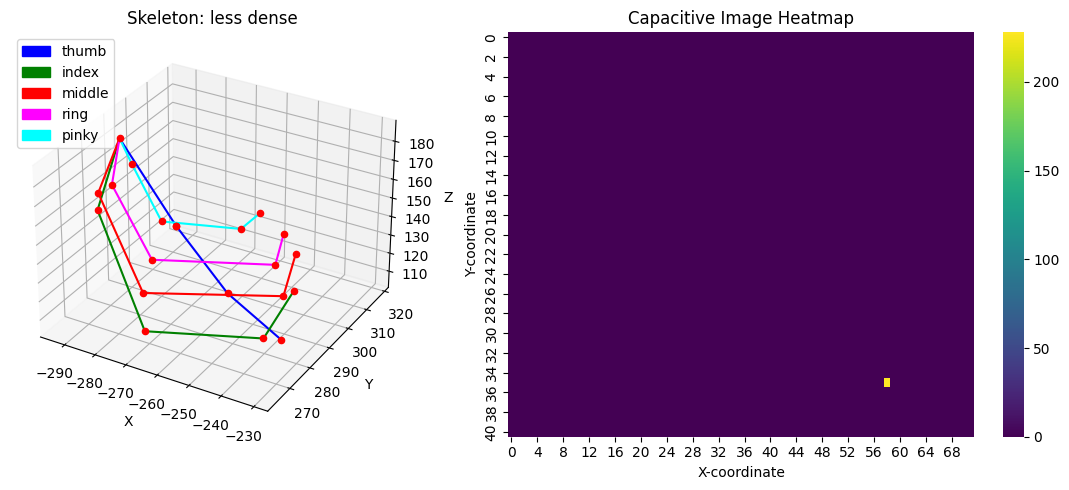

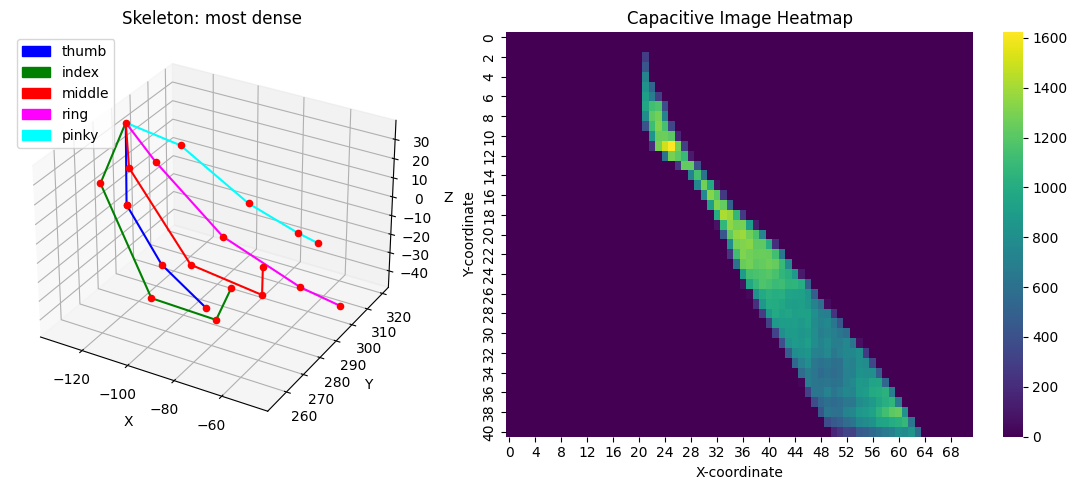

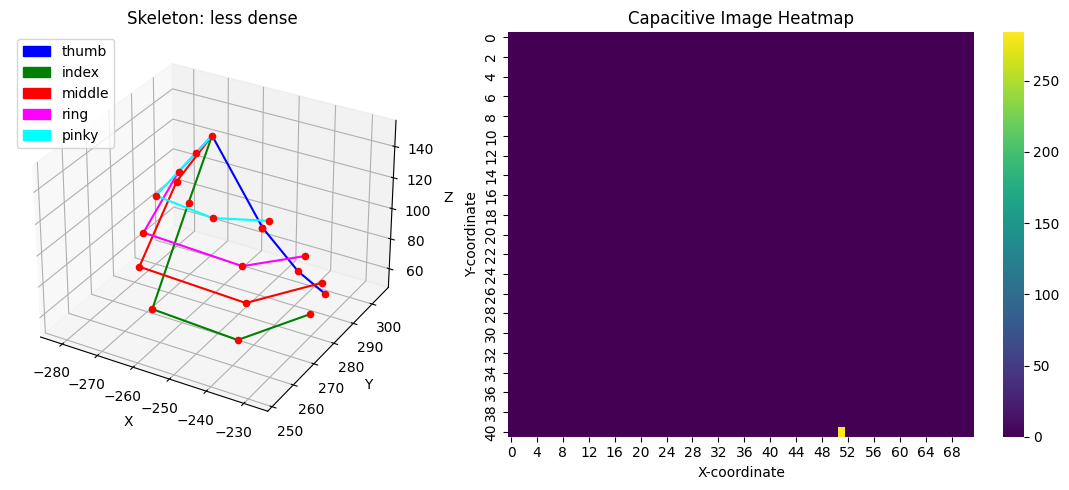

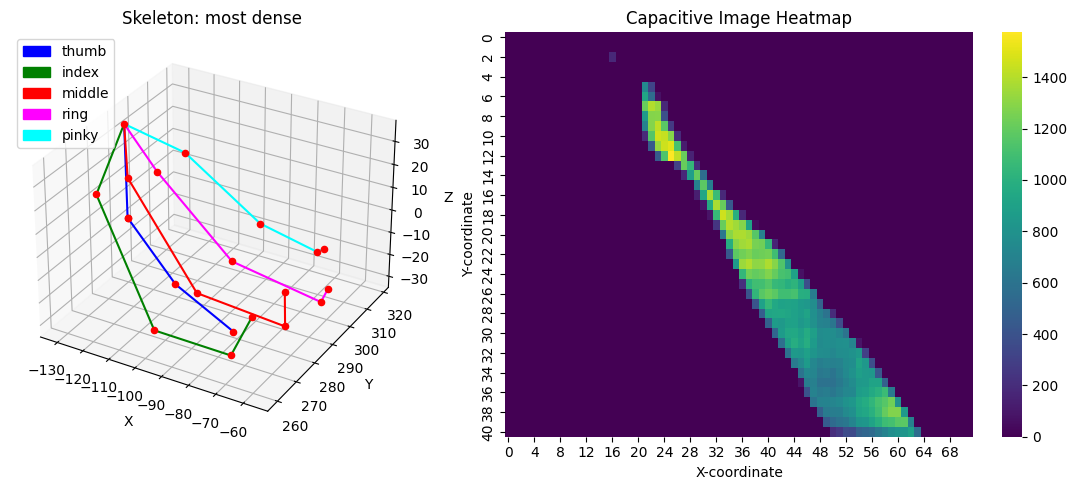

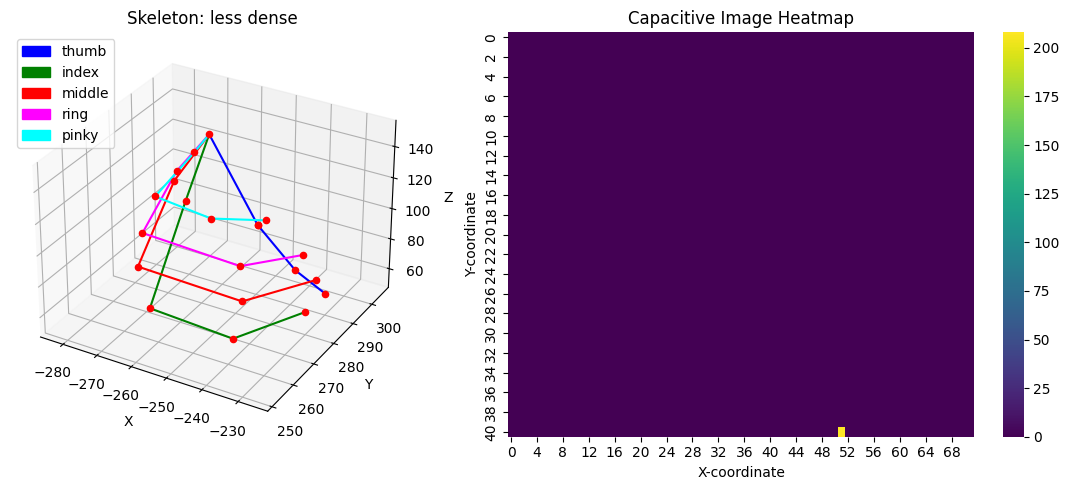

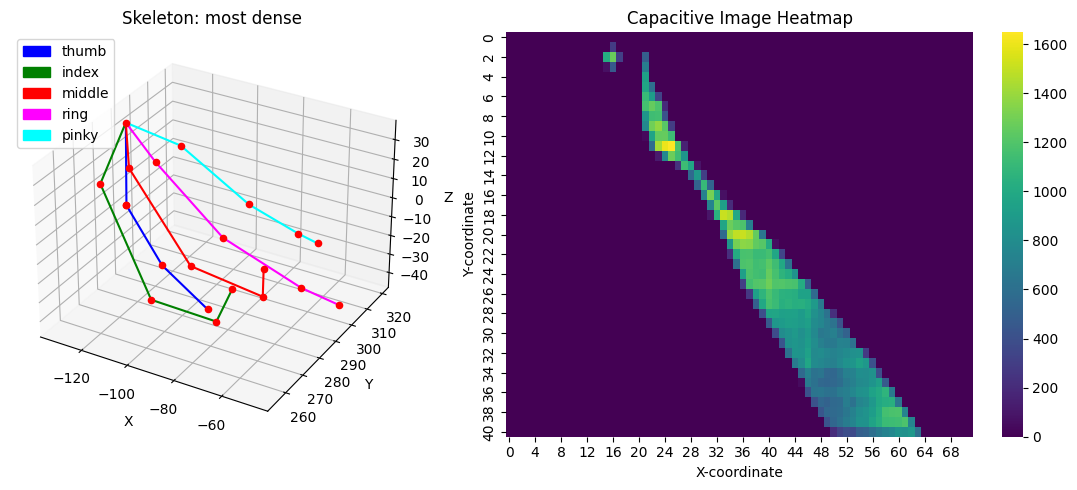

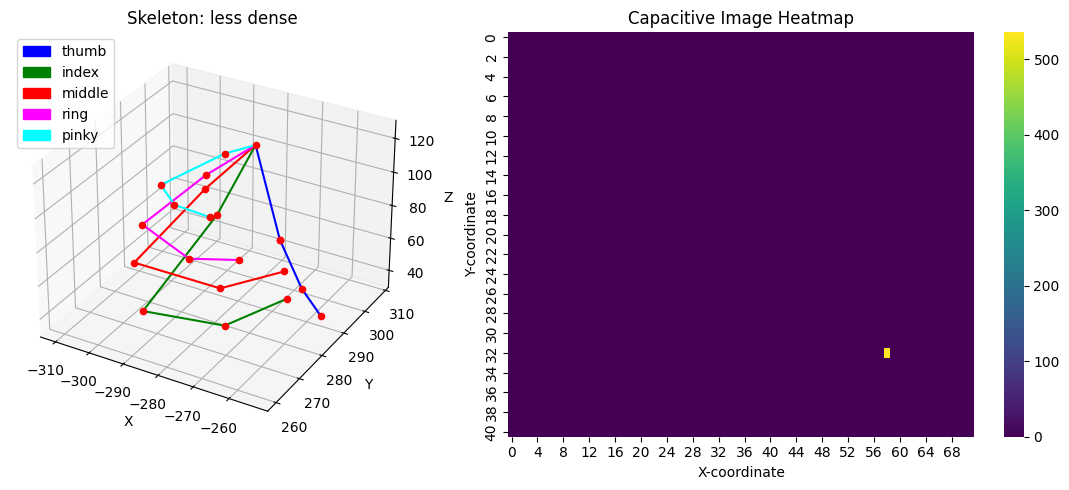

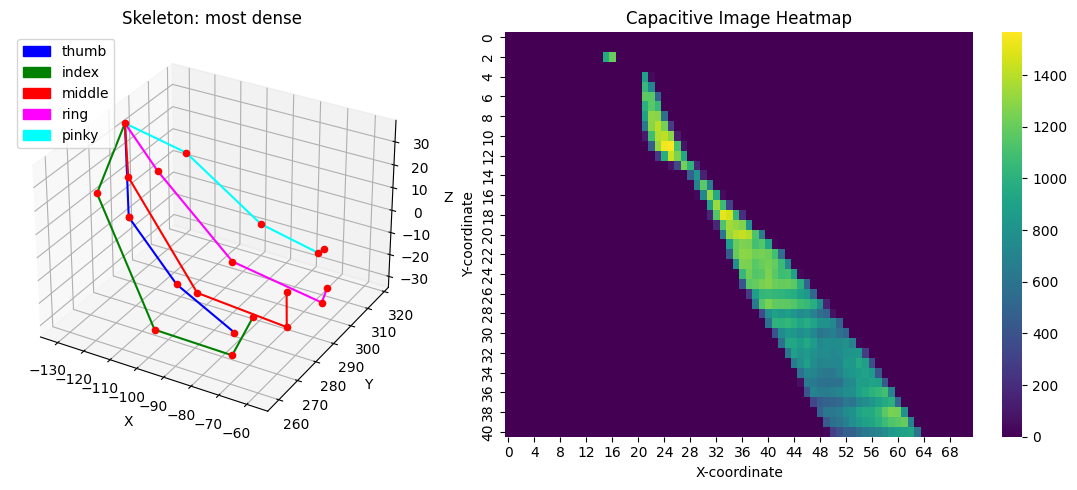

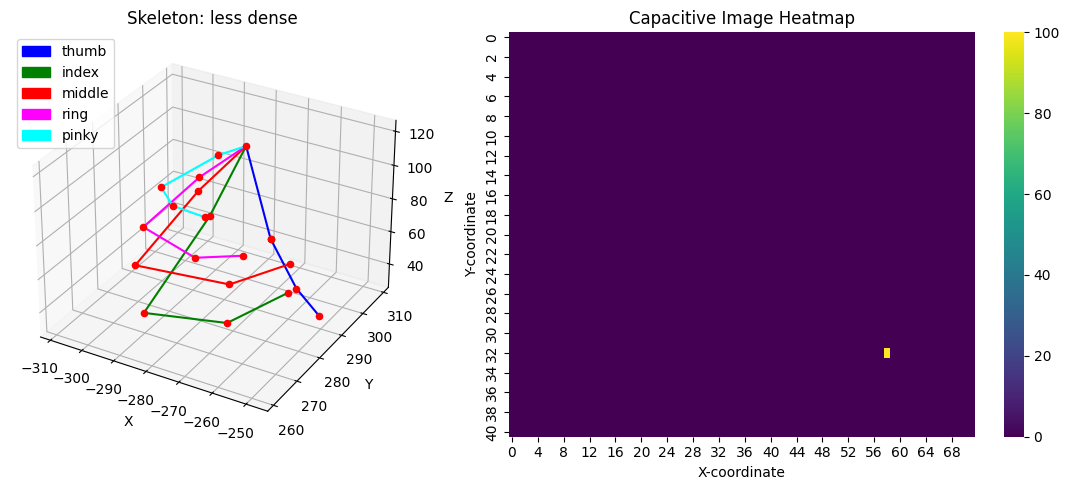

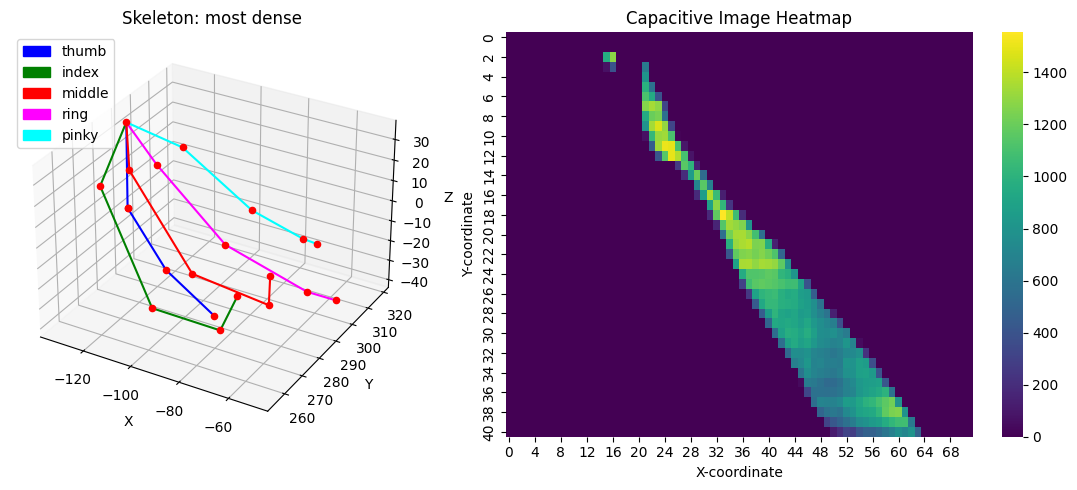

In [ ]:
for x_l, y_l, x_m, y_m in zip(x_less,y_less, x_most, y_most) :
  plot_skel_cap_img(y_l, x_l, title='less dense')
  plot_skel_cap_img(y_m, x_m, title='most dense')

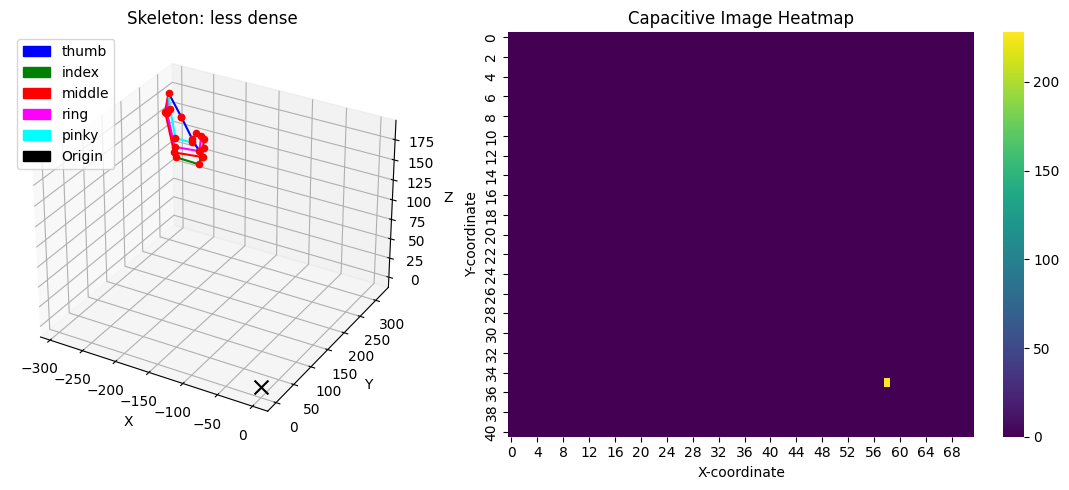

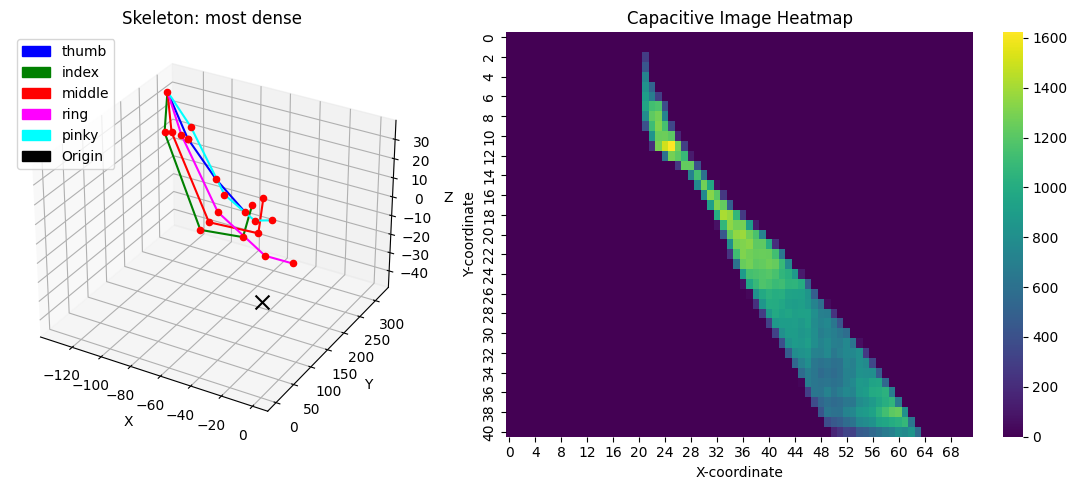

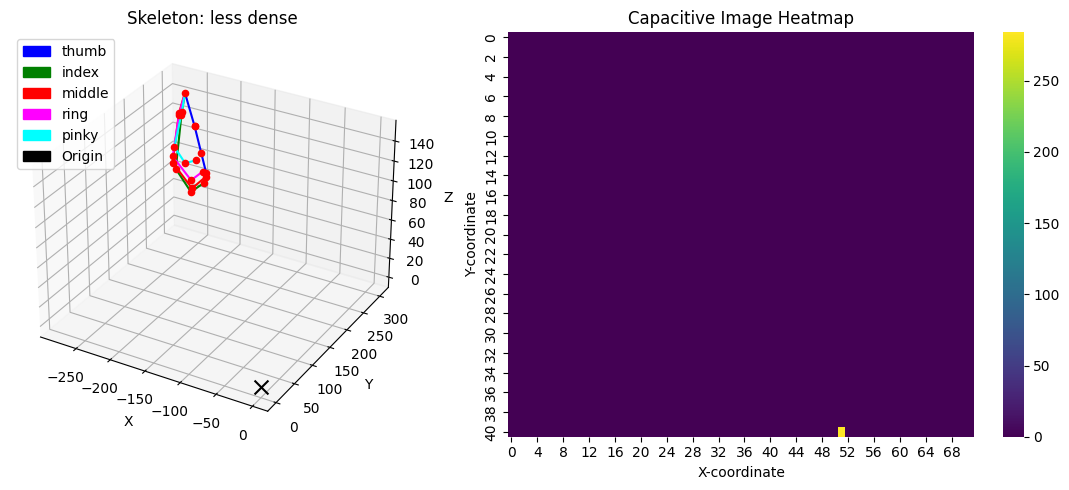

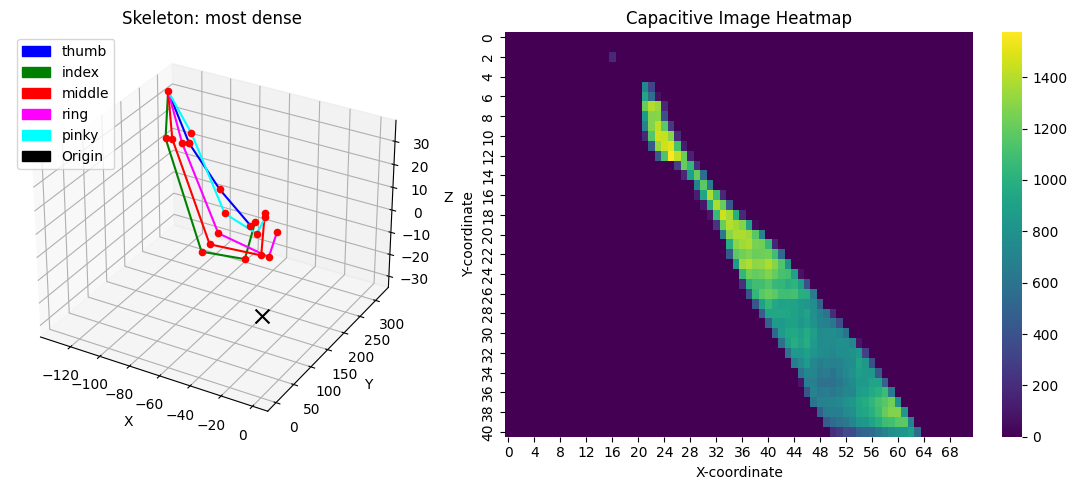

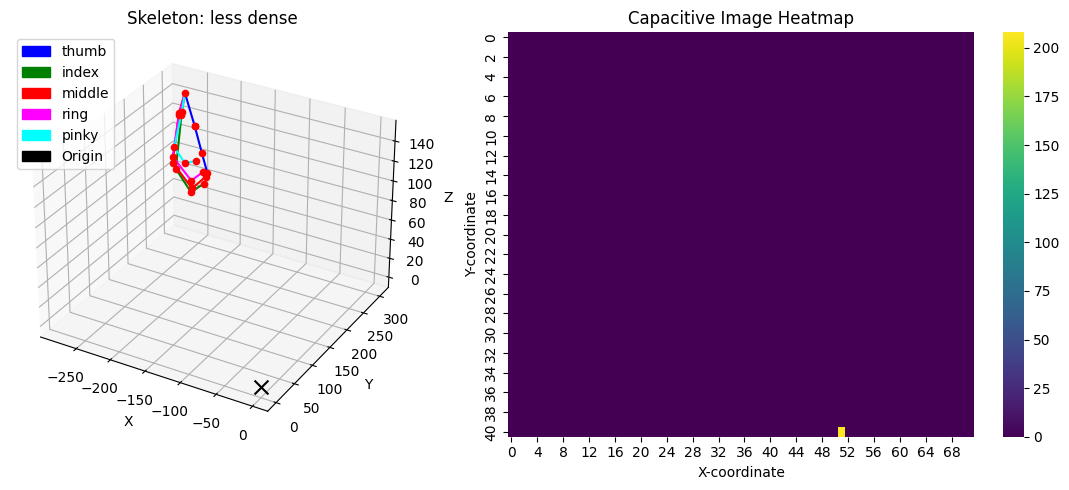

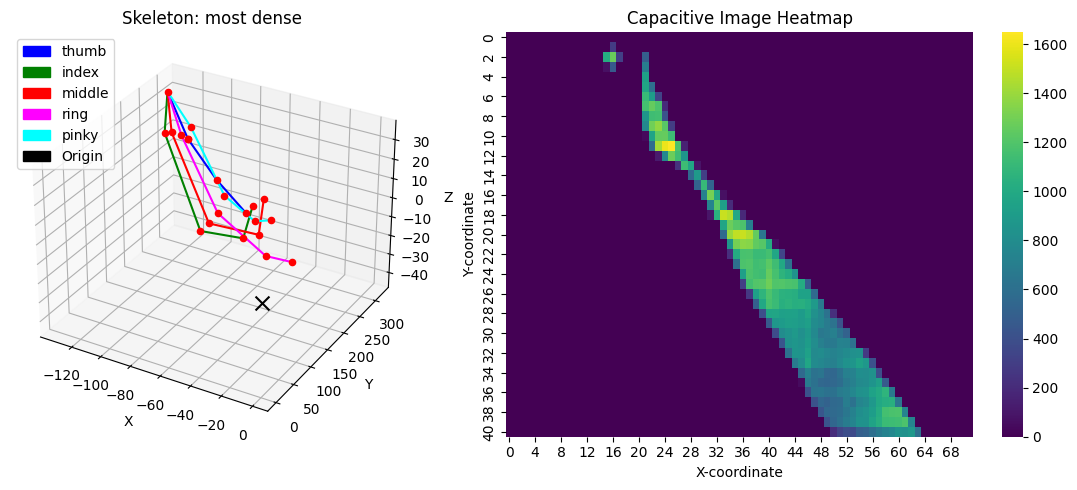

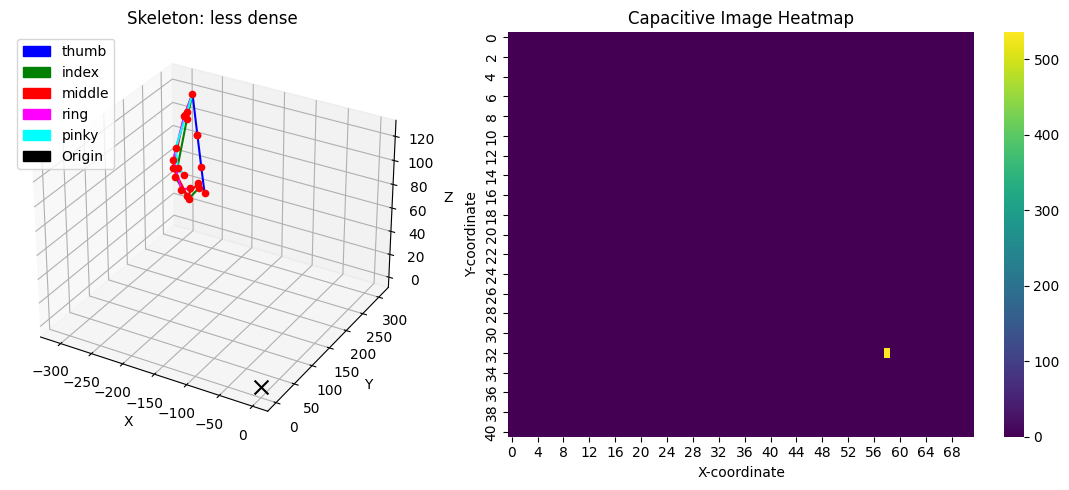

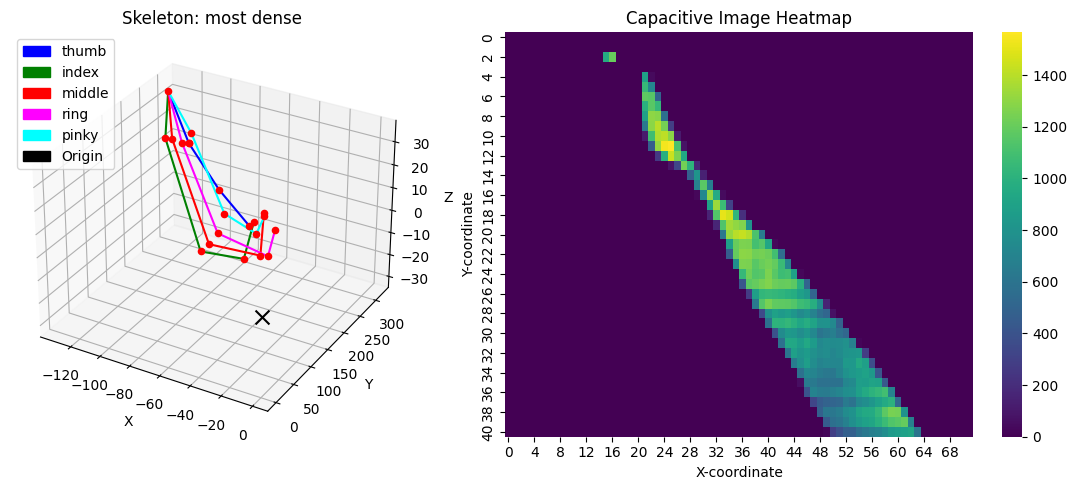

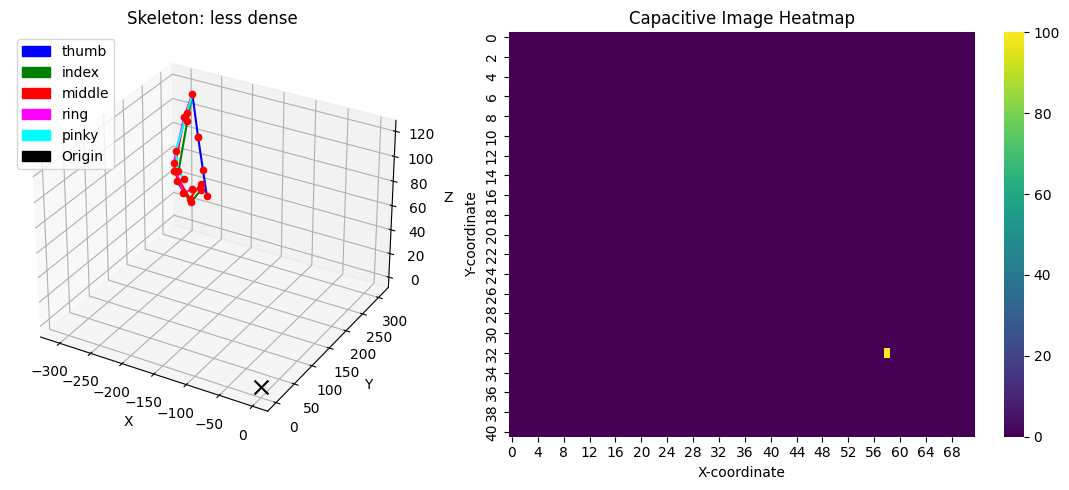

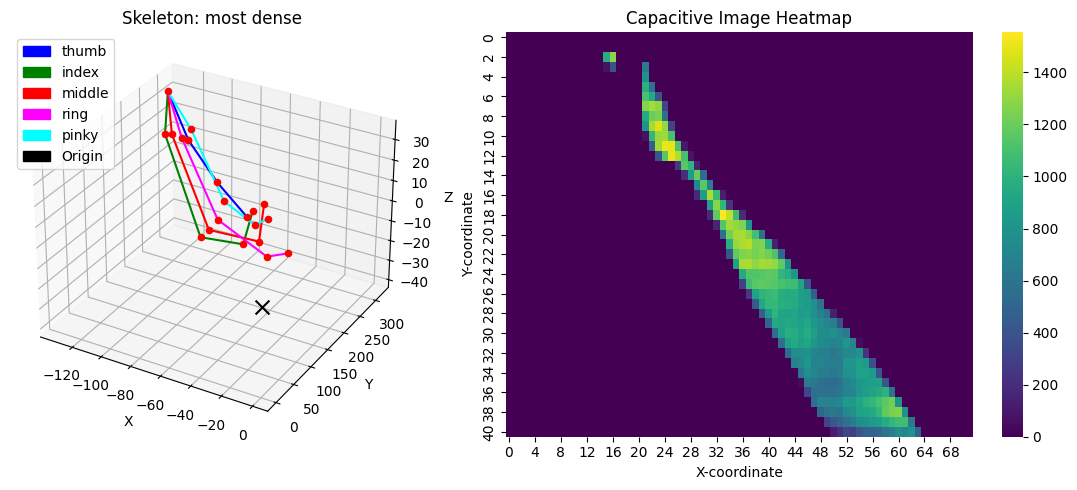

In [ ]:
for x_l, y_l, x_m, y_m in zip(x_less,y_less, x_most, y_most) :
  plot_skel_cap_img(y_l,x_l, title='less dense', camera_coords=True)
  plot_skel_cap_img(y_m,x_m, title='most dense', camera_coords=True)

### per gesture cap_img plot for touchpose data

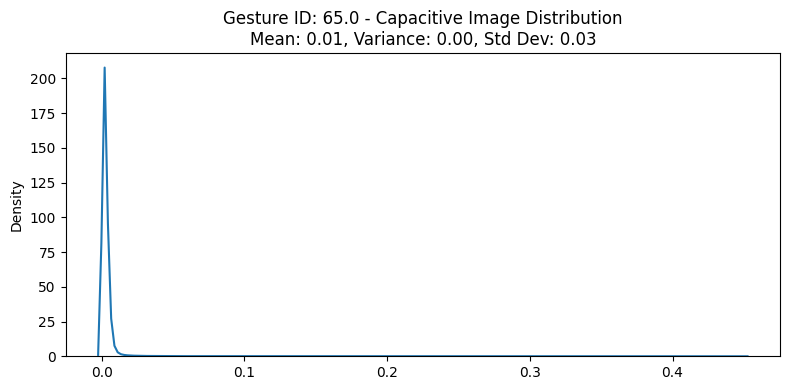

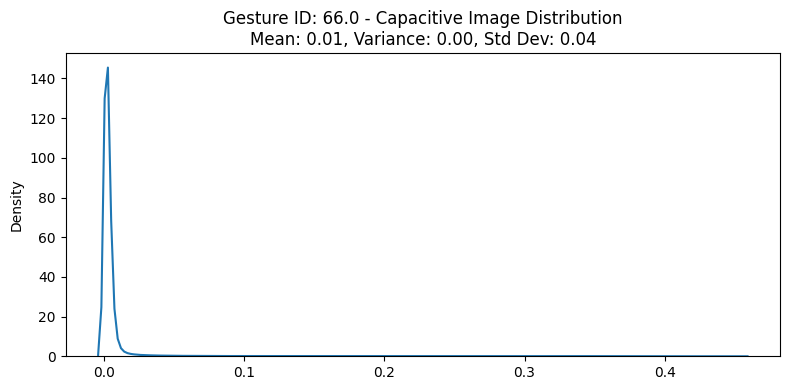

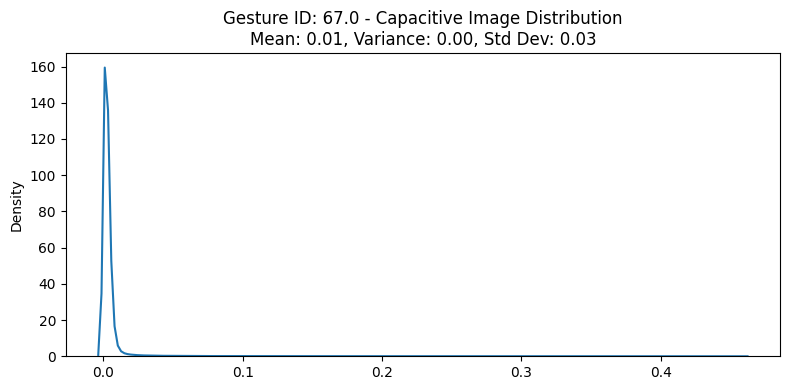

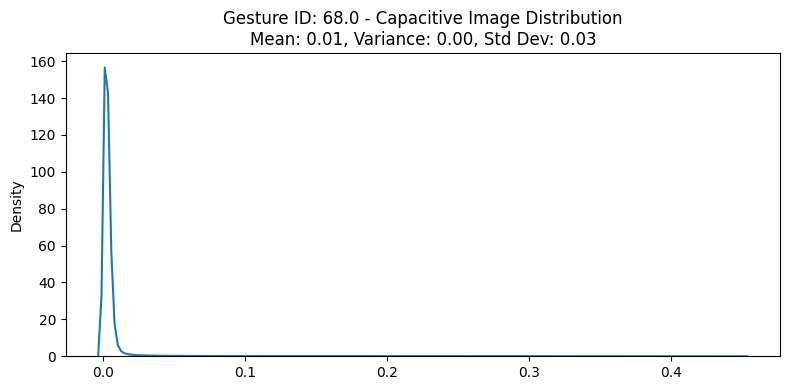

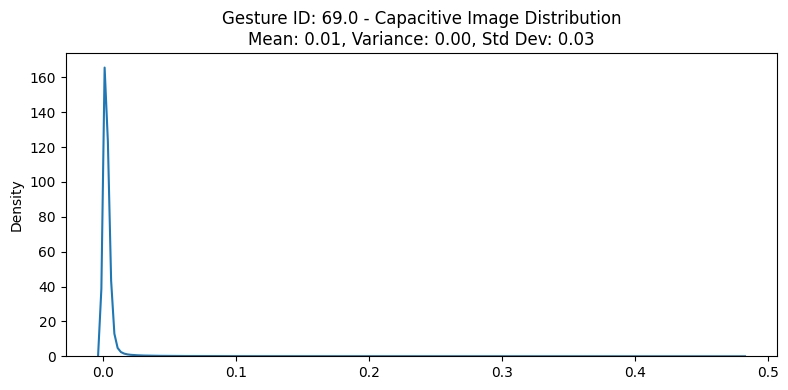

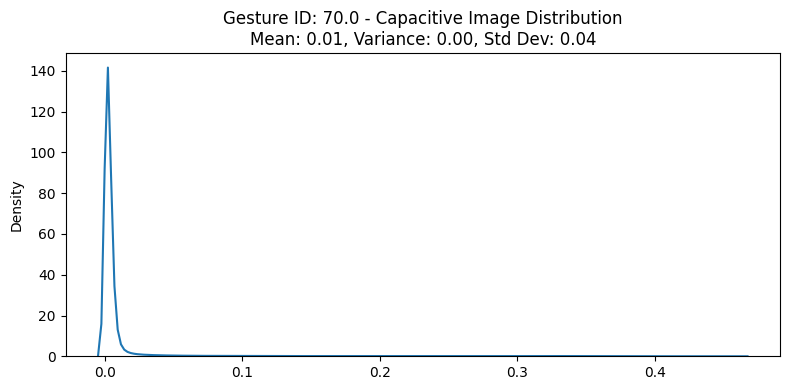

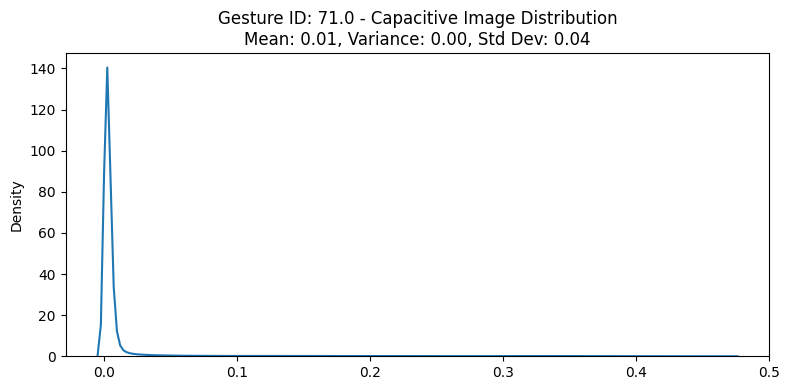

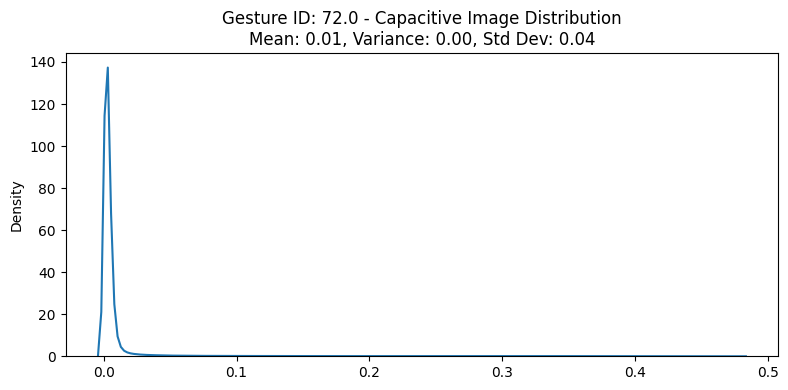

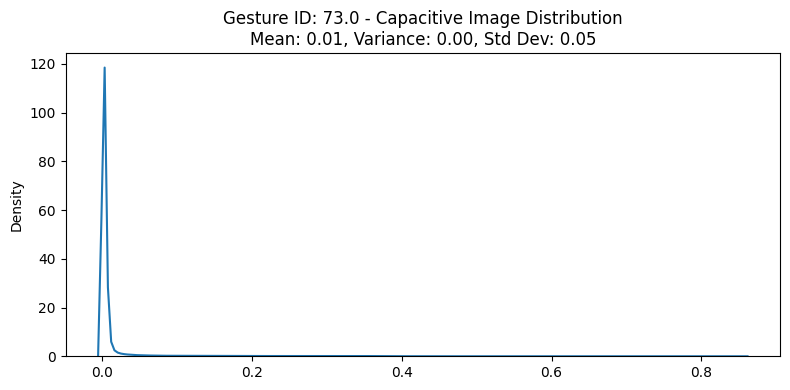

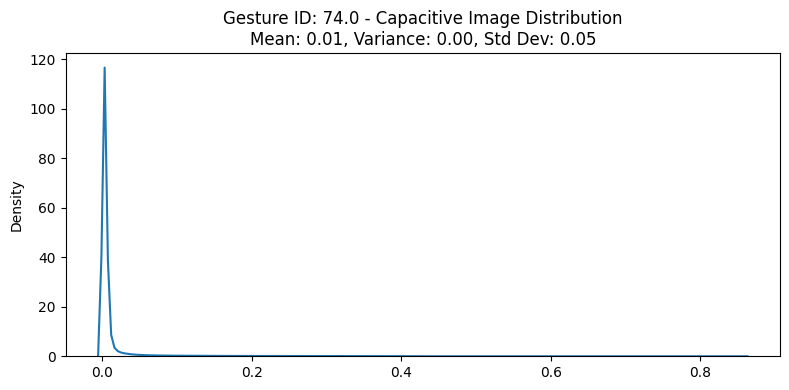

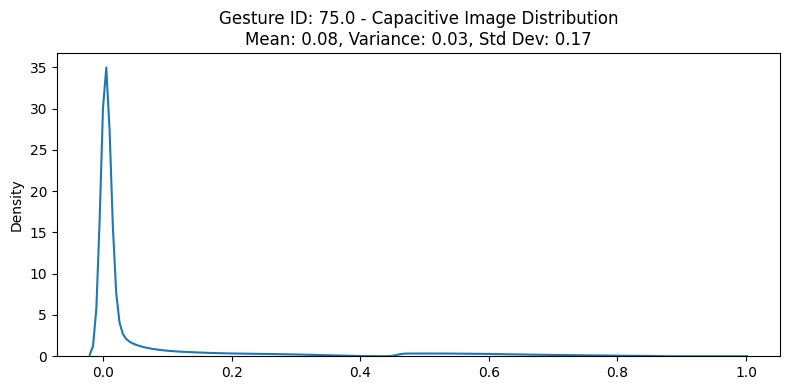

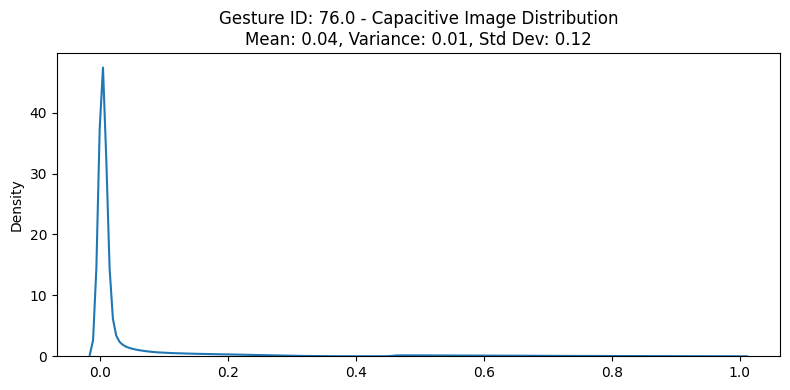

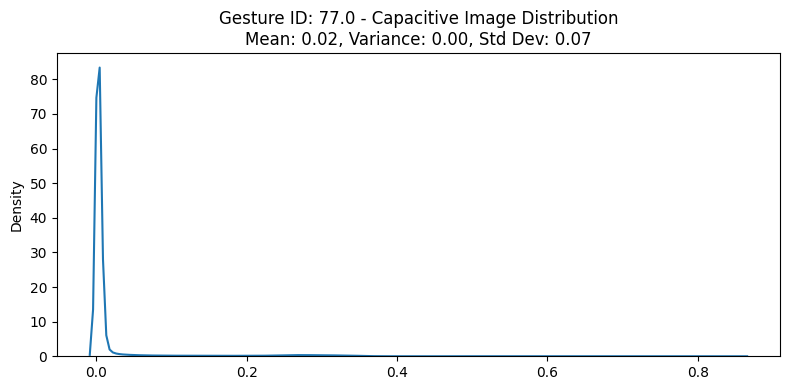

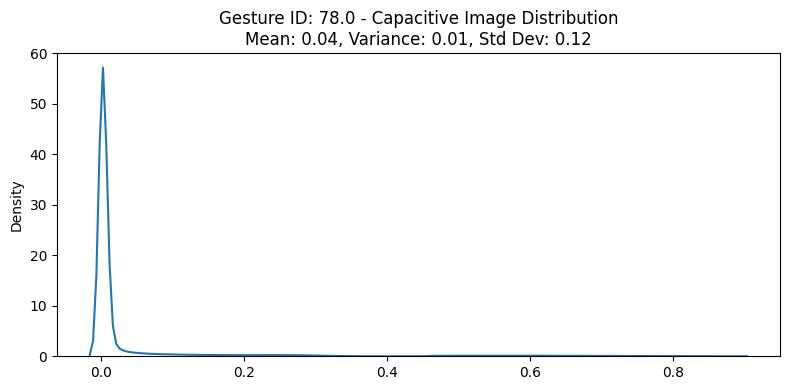

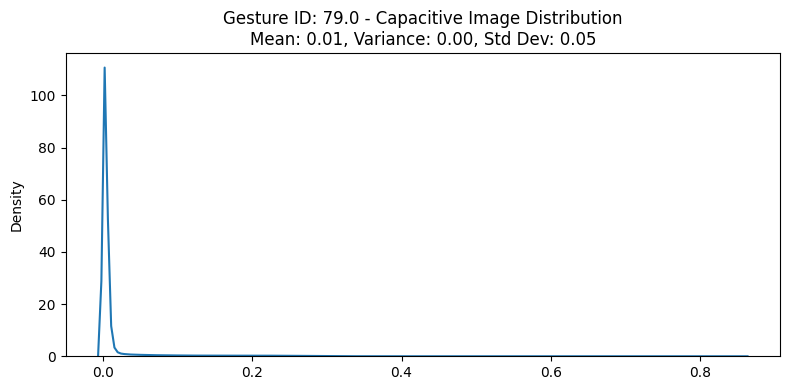

In [ ]:
gesture_groups_eth = df_eth.groupby('gesture_id')

for gesture_id, group_data in gesture_groups_eth:
    cap_eth = np.sort(np.concatenate(group_data.cap_img.values).flatten())
    cap_eth = np.where(cap_eth > 0, cap_eth, 0) / 1400
    index = np.argwhere(cap_eth == 0)
    cap_eth = np.delete(cap_eth, index)

    cap_eth_mean = np.mean(cap_eth)
    cap_eth_variance = np.var(cap_eth)
    cap_eth_std_dev = np.std(cap_eth)

    plt.figure(figsize=(8, 4))

    sns.kdeplot(cap_eth)
    plt.title(f'Gesture ID: {gesture_id} - Capacitive Image Distribution\nMean: {cap_eth_mean:.2f}, Variance: {cap_eth_variance:.2f}, Std Dev: {cap_eth_std_dev:.2f}')

    plt.tight_layout()
    plt.show()

# Capacitive images and skeleton comparison between training and testing

**time split**

In [ ]:
data=load_data(chili_data, 'time', 0.6, seed)

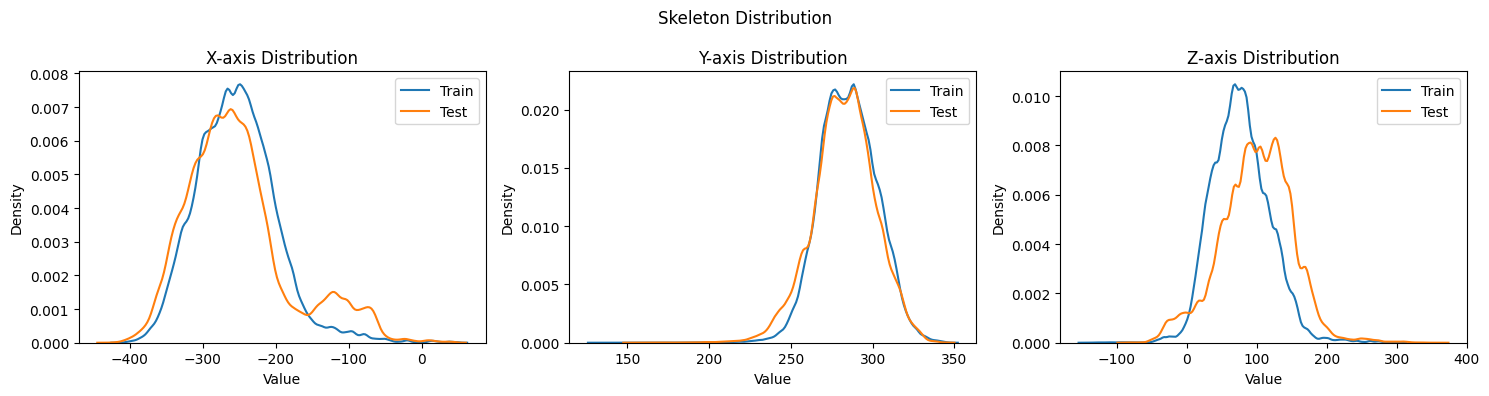

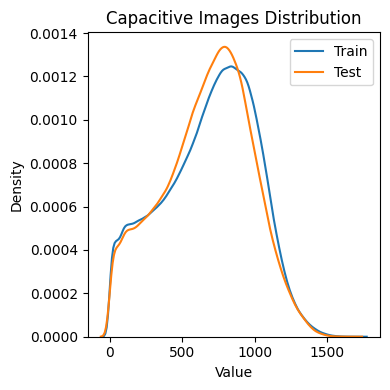

Percentage of zeroes in capactive train data 98.02683214209883
Percentage of zeroes in capacitive test data 98.49109628288203


In [ ]:
y_train_skeleton,y_test_skeleton = data['train']['y'].numpy()[:,:63], data['test']['y'].numpy()[:,:63]
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,data['train']['X'],data['test']['X'])

**train test split**

In [ ]:
data=load_data(chili_data, 'tr_test_split', 0.6, seed)

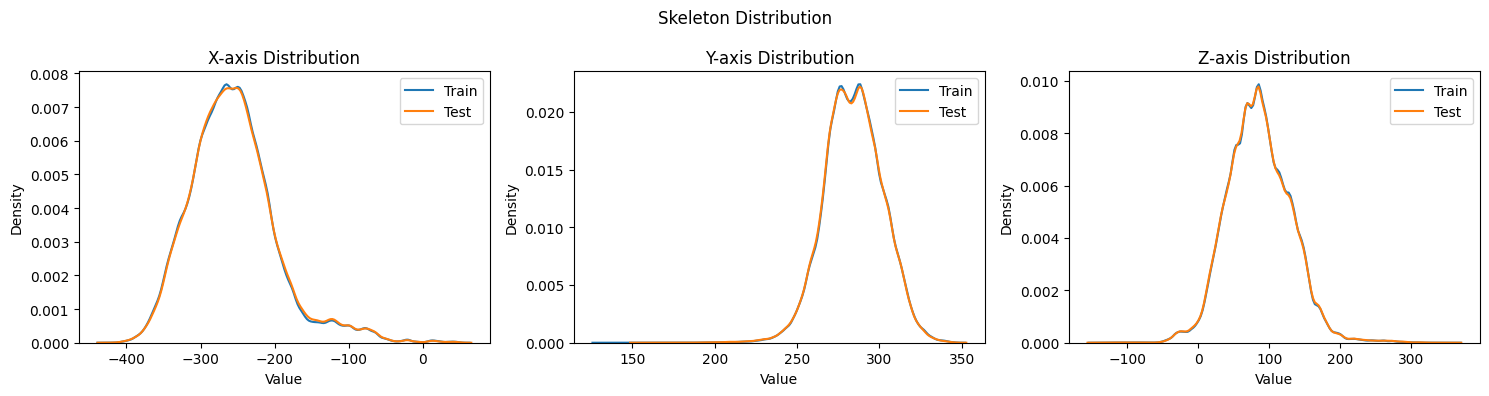

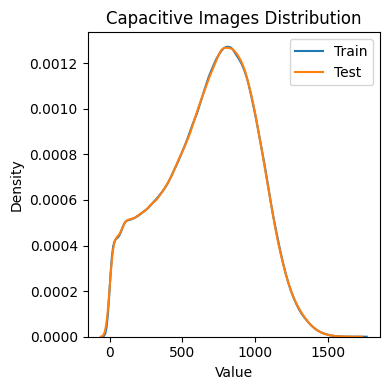

Percentage of zeroes in capactive train data 98.19134868926093
Percentage of zeroes in capacitive test data 98.17624230775411


In [ ]:
y_train_skeleton,y_test_skeleton = data['train']['y'].numpy()[:,:63], data['test']['y'].numpy()[:,:63]
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,data['train']['X'],data['test']['X'])

**cross gesture**

DQ


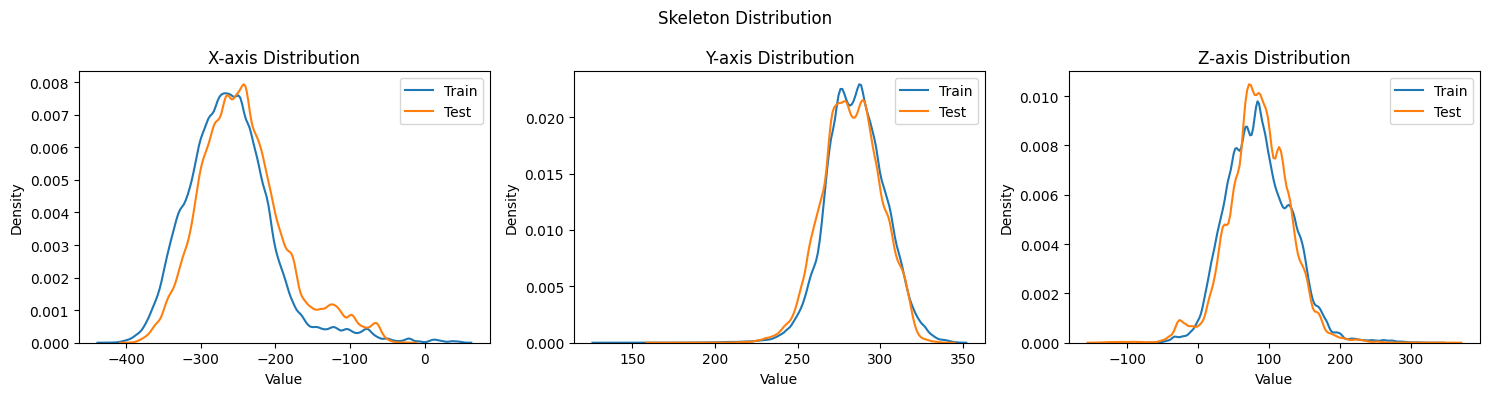

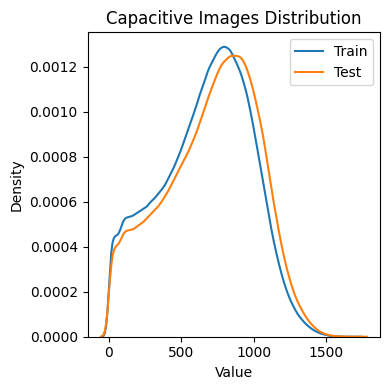

Percentage of zeroes in capactive train data 98.30612377398718
Percentage of zeroes in capacitive test data 97.87848973363936
**************************************************
DT


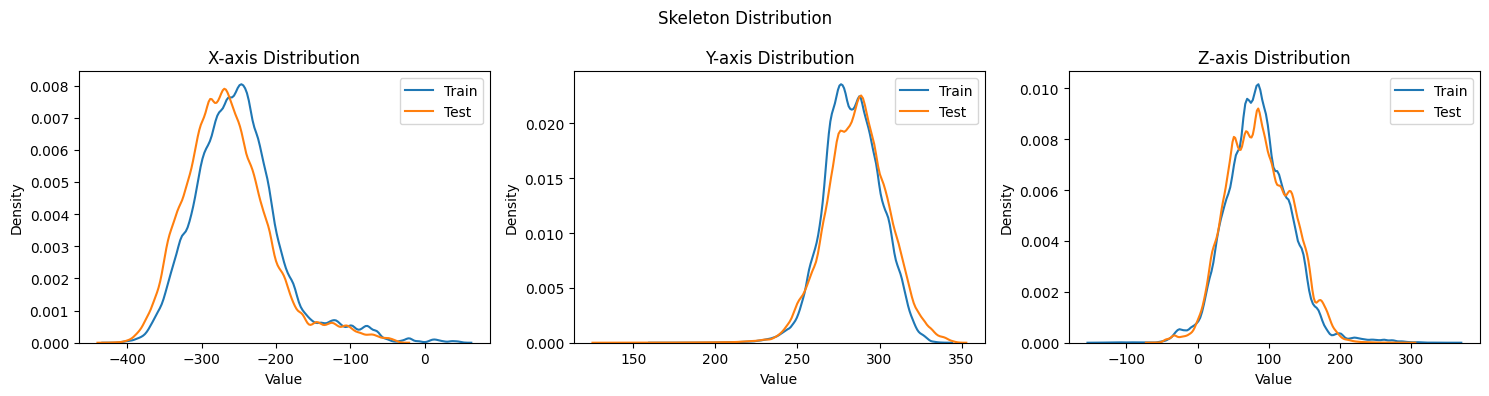

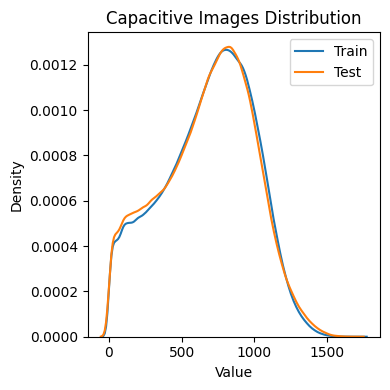

Percentage of zeroes in capactive train data 98.1773727872785
Percentage of zeroes in capacitive test data 98.20980212174038
**************************************************
LQ


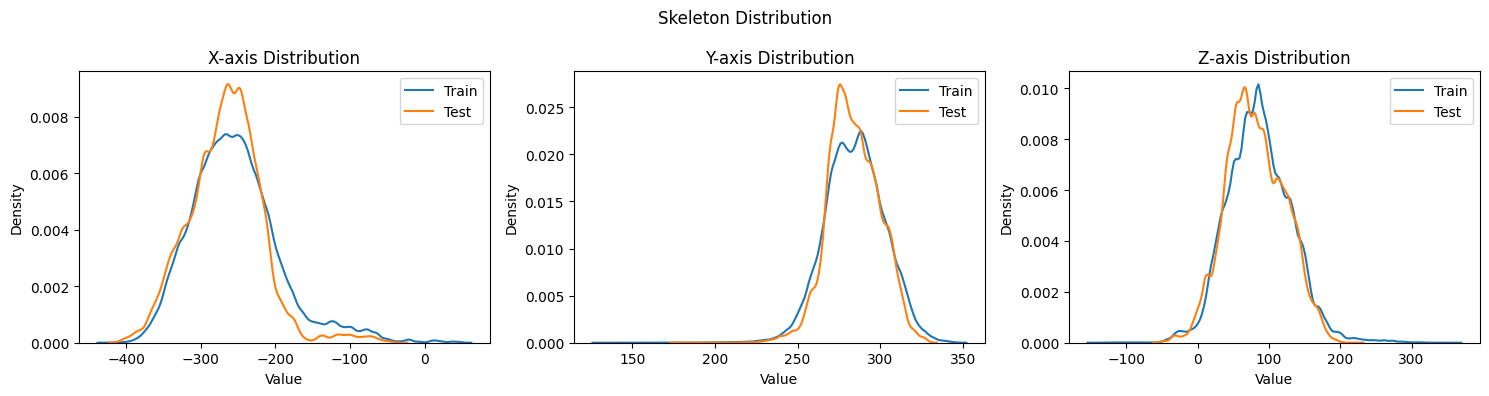

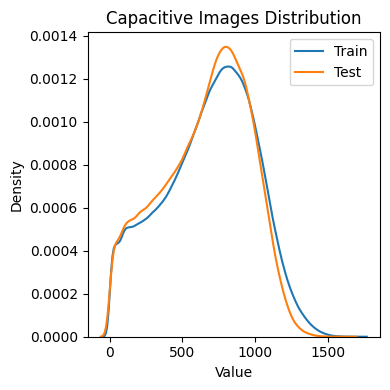

Percentage of zeroes in capactive train data 98.15922854830212
Percentage of zeroes in capacitive test data 98.3385501930191
**************************************************
LT


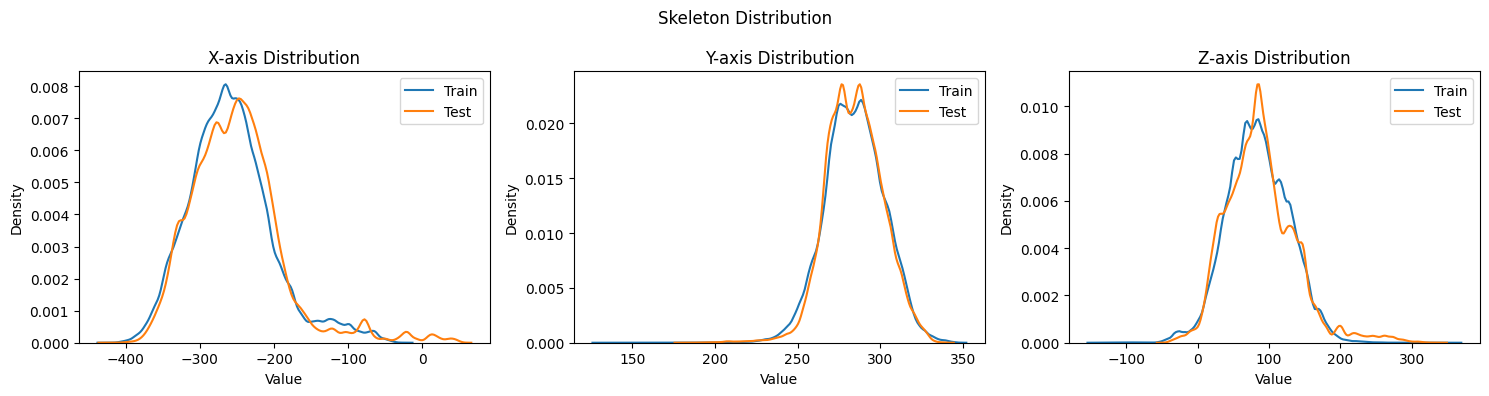

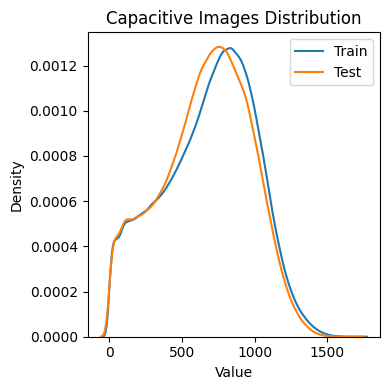

Percentage of zeroes in capactive train data 98.11665659698554
Percentage of zeroes in capacitive test data 98.41599752504062
**************************************************


In [ ]:
for g in chili_data.gesture.unique():
  #train_siye is irellevant here
  print(g)
  data=load_data(chili_data, 'cross', train_size=None, seed=seed, fold = g)
  y_train_skeleton,y_test_skeleton = data['train']['y'].numpy()[:,:63], data['test']['y'].numpy()[:,:63]
  plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,data['train']['X'],data['test']['X'])
  print('*'*50)